<!-- CELL 1 -->
## Section 0 — ICBHI 2017 Dataset Download & Verification

**What this cell does:**
1. Wipes any previous partial download in `/content/data` for a clean slate.
2. Authenticates to Kaggle using your `KAGGLE_API_TOKEN` (set via the 🔑 Colab Secrets sidebar).
3. Downloads the ICBHI 2017 mirror (`vbookshelf/respiratory-sound-database`, ~3.69GB) and unzips it.
4. Detects and removes a known duplicate-folder artifact this zip produces on extraction
   (case-sensitive filesystem creates both `respiratory_sound_database/` and
   `Respiratory_Sound_Database/` trees — only one is kept).
5. Auto-detects the canonical data paths (`DATA_ROOT`, `AUDIO_DIR`, `DIAGNOSIS_CSV`) so downstream
   cells don't hardcode a path that might shift between runs.
6. Sanity-checks the result: expects **920 `.wav` files**, **1840 total files** in the audio directory,
   and **126 patients** across 8 diagnosis classes (COPD 64 / Healthy 26 / URTI 14 / Bronchiectasis 7 /
   Bronchiolitis 6 / Pneumonia 6 / LRTI 2 / Asthma 1).

**Output variables used by later cells:** `DATA_ROOT`, `AUDIO_DIR`, `DIAGNOSIS_CSV`.


In [1]:
# ==================== CELL 2 ====================

# ============================================================
# ICBHI 2017 Dataset — Clean Download, Dedup, and Verify (single cell)
# ============================================================
import os, glob, subprocess
import pandas as pd
from google.colab import userdata

# --- 0. Skip the whole download if the dataset is already extracted in this runtime ---
_existing = glob.glob('/content/data/**/patient_diagnosis.csv', recursive=True)
_wavs = len(glob.glob('/content/data/**/*.wav', recursive=True))
SKIP_DOWNLOAD = len(_existing) == 1 and _wavs >= 900
if SKIP_DOWNLOAD:
    DIAGNOSIS_CSV = _existing[0]
    DATA_ROOT = os.path.dirname(DIAGNOSIS_CSV)
    AUDIO_DIR = f"{DATA_ROOT}/audio_and_txt_files"
    print(f"Dataset already present ({_wavs} wav files) — skipping download.")
    print("DATA_ROOT:", DATA_ROOT)

# --- 1. Clean slate (only when we actually need to download) ---
if not SKIP_DOWNLOAD:
    !rm -rf /content/data
    !mkdir -p /content/data

if not SKIP_DOWNLOAD:
    # --- 2. Kaggle auth (Colab Secrets: set KAGGLE_API_TOKEN in the 🔑 sidebar first) ---
    os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
    !pip install -q --upgrade kaggle

    # --- 3. Download & unzip ---
    !kaggle datasets download -d vbookshelf/respiratory-sound-database -p /content/data
    !unzip -q /content/data/respiratory-sound-database.zip -d /content/data
    !rm /content/data/respiratory-sound-database.zip

    # --- 4. Find all extracted diagnosis CSVs (checks for duplicate-tree issue) ---
    result = subprocess.run(['find', '/content/data', '-iname', 'patient_diagnosis.csv'],
                             capture_output=True, text=True)
    csv_paths = [p for p in result.stdout.strip().split('\n') if p]
    print("Found patient_diagnosis.csv at:")
    for p in csv_paths:
        print(" ", p)

    # --- 5. Remove known duplicate tree if present ---
    !rm -rf /content/data/respiratory_sound_database

    wav_total = len(glob.glob('/content/data/**/*.wav', recursive=True))
    print(f"\n.wav files after dedup: {wav_total} (expect 920)")

    # --- 6. Auto-detect canonical paths ---
    candidates = glob.glob('/content/data/**/patient_diagnosis.csv', recursive=True)
    assert len(candidates) == 1, f"Expected exactly 1 diagnosis csv, found {len(candidates)}: {candidates}"

    DIAGNOSIS_CSV = candidates[0]
    DATA_ROOT = os.path.dirname(DIAGNOSIS_CSV)
    AUDIO_DIR = f"{DATA_ROOT}/audio_and_txt_files"

    print("\nDATA_ROOT   :", DATA_ROOT)
    print("AUDIO_DIR   :", AUDIO_DIR)
    print("DIAGNOSIS   :", DIAGNOSIS_CSV)
    print("audio dir exists  :", os.path.exists(AUDIO_DIR))
    print("diagnosis exists  :", os.path.exists(DIAGNOSIS_CSV))
    print("files in audio dir:", len(os.listdir(AUDIO_DIR)), "(expect ~1840 = 920 wav + 920 txt)")
    print("wav files         :", len(glob.glob(f"{AUDIO_DIR}/*.wav")), "(expect 920)")

    # --- 7. Sanity-check diagnosis labels ---
    diagnosis_df = pd.read_csv(DIAGNOSIS_CSV, header=None, names=['patient_id', 'diagnosis'])
    print("\nDiagnosis distribution:")
    print(diagnosis_df['diagnosis'].value_counts())
    print(f"\nTotal patients: {len(diagnosis_df)} (expect 126)")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.8/256.8 kB 9.9 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/vbookshelf/respiratory-sound-database
License(s): unknown
100% 3.69G/3.69G [00:28<00:00, 141MB/s]

Found patient_diagnosis.csv at:
  /content/data/respiratory_sound_database/Respiratory_Sound_Database/patient_diagnosis.csv
  /content/data/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv

.wav files after dedup: 920 (expect 920)

DATA_ROOT   : /content/data/Respiratory_Sound_Database/Respiratory_Sound_Database
AUDIO_DIR   : /content/data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
DIAGNOSIS   : /content/data/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv
audio dir exists  : True
diagnosis exists  : True
files in audio dir: 1840 (expect ~1840 = 920 wav + 920 txt)
wav files         : 920 (expect 920)

D

<!-- CELL 3 -->
# M7 — Deep Ensemble (N=5) — Member D
### Open-World Multi-Task Learning for Respiratory Disease Diagnosis

**Model ID:** M7 | **Owner:** Member D | **Backbone:** Pretrained MobileNetV2 (ImageNet) — dual-head (sound-event + disease)

**Objective:** Train 5 independently-seeded ensemble members on ICBHI 2017. Report full metric suite per member,
plus ensemble-disagreement unknown-detection AUROC/AUPR (gold-standard epistemic-uncertainty baseline).
Includes clean and SpecAugment-augmented runs per faculty requirement #5.

**Assumes:** Section 0 (dataset download) has already been run in this same notebook, producing
`DATA_ROOT`, `AUDIO_DIR`, and `DIAGNOSIS_CSV` in memory.


<!-- CELL 4 -->
## Section 1 — Environment Setup & Dependencies

In [2]:
# ==================== CELL 5 ====================

# ---------------------------------------------------------------------------
# PERSISTENT STORAGE — mount Google Drive FIRST.
# /content is wiped when the runtime dies. Google Drive is not. Every checkpoint
# in this notebook is written to Drive, so training resumes after a RAM crash,
# a disconnect, a new session, a different account, or a different machine.
# ---------------------------------------------------------------------------
USE_DRIVE = True          # set False only if you genuinely don't want Drive
DRIVE_ROOT = None
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')          # approve the popup once per session
        DRIVE_ROOT = '/content/drive/MyDrive'
        print("Google Drive mounted — checkpoints will survive runtime resets.")
    except Exception as e:
        print(f"[WARNING] Drive not mounted ({e}). Falling back to /content, which is "
              f"WIPED on disconnect. Fix this before starting a long run.")

!pip install -q torchaudio librosa soundfile scikit-learn seaborn tqdm

import os, json, time, glob, random, tempfile, warnings, zipfile, gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
import librosa

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

def print_ram_usage(tag=""):
    """Lightweight RAM/VRAM checkpoint printout — call this between members if you want to
    watch for memory creep during a long run."""
    try:
        import psutil
        vm = psutil.virtual_memory()
        print(f"[RAM {tag}] used {vm.used/1e9:.2f} GB / {vm.total/1e9:.2f} GB ({vm.percent}%)", end="  ")
    except ImportError:
        print(f"[RAM {tag}] (install psutil for RAM stats)", end="  ")
    if torch.cuda.is_available():
        print(f"| [VRAM {tag}] allocated {torch.cuda.memory_allocated()/1e9:.2f} GB, "
              f"reserved {torch.cuda.memory_reserved()/1e9:.2f} GB")
    else:
        print()

print_ram_usage("startup")


Mounted at /content/drive
Google Drive mounted — checkpoints will survive runtime resets.
Device: cuda
GPU: Tesla T4
[RAM startup] used 1.69 GB / 13.61 GB (14.9%)  | [VRAM startup] allocated 0.00 GB, reserved 0.00 GB


<!-- CELL 6 -->
## Section 2 — Configuration & Hyperparameters

In [3]:
# ==================== CELL 7 ====================

# Everything under PERSIST_ROOT survives runtime death. If Drive mounted in Cell 5 we
# use it; otherwise we degrade to /content and warn loudly.
PERSIST_ROOT = DRIVE_ROOT if ("DRIVE_ROOT" in dir() and DRIVE_ROOT) else "/content"

CONFIG = {
    # --- shared audio preprocessing (protocol §2) ---
    "sample_rate": 16000,
    "duration": 8.0,
    "n_mels": 128,
    "n_fft": 1024,
    "hop_length": 160,
    "win_length": 400,
    "f_min": 50,
    "f_max": 2000,
    "seed": 42,

    # --- data paths ---
    # NOTE: DATA_ROOT / AUDIO_DIR / DIAGNOSIS_CSV are set by Section 0 (auto-detected from the
    # actual extracted zip structure). This hardcoded value is only a fallback if Section 0 wasn't run.
    "data_root": "/content/data/Respiratory_Sound_Database/Respiratory_Sound_Database",

    # --- known / unknown disease classes ---
    "known_classes": ["COPD", "Healthy", "URTI"],
    "unknown_classes": ["Bronchiectasis", "Pneumonia", "Bronchiolitis"],
    # LRTI (n=2) and Asthma (n=1) excluded: too few patients to be usable in either split

    # --- sound event labels ---
    "sound_event_classes": ["Normal", "Crackle", "Wheeze", "Both"],

    # --- splits ---
    "test_size": 0.4,           # patient-independent 60/40 on known-class patients
    "calibration_frac": 0.2,    # carved from the 60% train patients, held out from training

    # --- ensemble ---
    "ensemble_seeds": [42, 43, 44, 45, 46],   # N=5 independently-seeded members

    # --- training ---
    "batch_size": 16,
    "num_epochs": 15,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "optimizer": "Adam",
    "scheduler": "StepLR",
    "sound_event_weight": 1.0,
    "disease_weight": 1.0,
    "early_stopping_patience": 4,   # stop a member if val_combined_f1 hasn't improved in N epochs

    # --- regularization: freeze most of the pretrained backbone ---
    # 104 known-class patients is too little data to safely fine-tune all 3.5M backbone params;
    # only the last N feature blocks + both heads are trainable.
    "freeze_backbone": True,
    "unfreeze_last_n_blocks": 3,

    # --- checkpointing (see PERSIST_ROOT below) ---
    "ckpt_dir": f"{PERSIST_ROOT}/M7_project/checkpoints",     # Drive: survives everything
    "results_dir": f"{PERSIST_ROOT}/M7_project/results",      # Drive: survives everything
    "local_ckpt_dir": "/content/checkpoints_M7_local",        # fast scratch mirror
    # mid-epoch checkpoint every N batches -> a RAM crash costs at most N batches,
    # not the whole epoch. Set to 0 to disable, raise it if saving feels frequent.
    "mid_epoch_ckpt_every": 25,
}

os.makedirs(CONFIG["ckpt_dir"], exist_ok=True)
os.makedirs(CONFIG["results_dir"], exist_ok=True)
os.makedirs(CONFIG["local_ckpt_dir"], exist_ok=True)
print("Checkpoints ->", CONFIG["ckpt_dir"])
if not CONFIG["ckpt_dir"].startswith("/content/drive"):
    print("[WARNING] checkpoints are NOT on Google Drive — they will be lost if the "
          "runtime disconnects. Re-run Cell 5 and mount Drive.")

AUDIO_DIR = AUDIO_DIR if "AUDIO_DIR" in dir() else f'{CONFIG["data_root"]}/audio_and_txt_files'
DIAGNOSIS_CSV = DIAGNOSIS_CSV if "DIAGNOSIS_CSV" in dir() else f'{CONFIG["data_root"]}/patient_diagnosis.csv'
assert os.path.exists(AUDIO_DIR), f"Audio dir not found: {AUDIO_DIR}"
assert os.path.exists(DIAGNOSIS_CSV), f"Diagnosis csv not found: {DIAGNOSIS_CSV}"
print("Paths OK.")
print("AUDIO_DIR:", AUDIO_DIR)
print("DIAGNOSIS_CSV:", DIAGNOSIS_CSV)
print(CONFIG)


Checkpoints -> /content/drive/MyDrive/M7_project/checkpoints
Paths OK.
AUDIO_DIR: /content/data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
DIAGNOSIS_CSV: /content/data/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv
{'sample_rate': 16000, 'duration': 8.0, 'n_mels': 128, 'n_fft': 1024, 'hop_length': 160, 'win_length': 400, 'f_min': 50, 'f_max': 2000, 'seed': 42, 'data_root': '/content/data/Respiratory_Sound_Database/Respiratory_Sound_Database', 'known_classes': ['COPD', 'Healthy', 'URTI'], 'unknown_classes': ['Bronchiectasis', 'Pneumonia', 'Bronchiolitis'], 'sound_event_classes': ['Normal', 'Crackle', 'Wheeze', 'Both'], 'test_size': 0.4, 'calibration_frac': 0.2, 'ensemble_seeds': [42, 43, 44, 45, 46], 'batch_size': 16, 'num_epochs': 15, 'lr': 0.0001, 'weight_decay': 0.0001, 'optimizer': 'Adam', 'scheduler': 'StepLR', 'sound_event_weight': 1.0, 'disease_weight': 1.0, 'early_stopping_patience': 4, 'freeze_backbone': True, 'unfreez

<!-- CELL 8 -->
## Section 3 — Dataset Loading & Patient-Independent Splitting

**Steps:**
1. Parse `patient_diagnosis.csv` for patient-level disease labels.
2. Parse every `.txt` annotation file into individual respiratory cycles, label each Normal/Crackle/Wheeze/Both.
3. Filter to known-class patients (COPD/Healthy/URTI = 104) for training/testing; keep unknown-class patients
   (Bronchiectasis/Pneumonia/Bronchiolitis = 19) fully held out for OOD/unknown-detection evaluation only.
4. Patient-independent 60/40 train/test split on known-class patients (stratified by diagnosis).
5. Carve a held-out **calibration partition** from the training patients (Member D's own contribution —
   never used for training, reserved for later calibration work in M11/M14).


In [4]:
# ==================== CELL 9 ====================

def parse_diagnosis(csv_path):
    df = pd.read_csv(csv_path, header=None, names=["patient_id", "diagnosis"])
    df["patient_id"] = df["patient_id"].astype(str)
    return dict(zip(df["patient_id"], df["diagnosis"]))

def sound_event_label(crackle, wheeze):
    if crackle == 0 and wheeze == 0: return "Normal"
    if crackle == 1 and wheeze == 0: return "Crackle"
    if crackle == 0 and wheeze == 1: return "Wheeze"
    return "Both"

def parse_cycles(txt_path):
    cycles = []
    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) != 4:
                parts = line.strip().split()
            if len(parts) != 4:
                continue
            start, end, crackle, wheeze = parts
            cycles.append({
                "start": float(start),
                "end": float(end),
                "label": sound_event_label(int(float(crackle)), int(float(wheeze))),
            })
    return cycles

diagnosis_map = parse_diagnosis(DIAGNOSIS_CSV)

wav_files = sorted(glob.glob(f"{AUDIO_DIR}/*.wav"))
print(f"Found {len(wav_files)} wav files")

records = []
for wav_path in wav_files:
    fname = os.path.basename(wav_path)
    patient_id = fname.split("_")[0]
    txt_path = wav_path.replace(".wav", ".txt")
    if not os.path.exists(txt_path):
        continue
    diagnosis = diagnosis_map.get(patient_id, None)
    if diagnosis is None:
        continue
    cycles = parse_cycles(txt_path)
    for i, c in enumerate(cycles):
        records.append({
            "patient_id": patient_id,
            "wav_path": wav_path,
            "cycle_idx": i,
            "start": c["start"],
            "end": c["end"],
            "sound_event_label": c["label"],
            "diagnosis": diagnosis,
        })

manifest = pd.DataFrame(records)
del records
gc.collect()
print(f"Total cycles parsed: {len(manifest)}  (expect ~6898)")
print(manifest["sound_event_label"].value_counts())
print(manifest["diagnosis"].value_counts())


Found 920 wav files
Total cycles parsed: 6898  (expect ~6898)
sound_event_label
Normal     3642
Crackle    1864
Wheeze      886
Both        506
Name: count, dtype: int64
diagnosis
COPD              5746
Healthy            322
Pneumonia          285
URTI               243
Bronchiolitis      160
Bronchiectasis     104
LRTI                32
Asthma               6
Name: count, dtype: int64


In [5]:
# ==================== CELL 10 ====================

# --- known / unknown patient split ---
known_classes = CONFIG["known_classes"]
unknown_classes = CONFIG["unknown_classes"]

known_manifest = manifest[manifest["diagnosis"].isin(known_classes)].reset_index(drop=True)
unknown_manifest = manifest[manifest["diagnosis"].isin(unknown_classes)].reset_index(drop=True)

known_patients = known_manifest[["patient_id", "diagnosis"]].drop_duplicates()
print(f"Known-class patients: {len(known_patients)} (expect 104)")
print(known_patients['diagnosis'].value_counts())

unknown_patients = unknown_manifest[["patient_id", "diagnosis"]].drop_duplicates()
print(f"\nUnknown-class (held-out) patients: {len(unknown_patients)} (expect 19)")
print(unknown_patients['diagnosis'].value_counts())

# --- patient split: cached to Drive so it's identical every session, not just "probably
# identical" via random_state. Recomputing train_test_split fresh each session relies on the
# installed library versions and file-listing order staying byte-identical forever; caching
# the actual patient IDs removes that dependency entirely and also skips the recompute. ---
_split_cache_path = f'{CONFIG["results_dir"]}/patient_split.json'

if os.path.exists(_split_cache_path):
    with open(_split_cache_path) as f:
        _split = json.load(f)
    train_only_patients = np.array(_split["train_only_patients"])
    calibration_patients = np.array(_split["calibration_patients"])
    test_patients = np.array(_split["test_patients"])
    print(f"\nLoaded cached patient split from {_split_cache_path} "
          f"(train={len(train_only_patients)}, calib={len(calibration_patients)}, test={len(test_patients)})")
else:
    train_patients, test_patients = train_test_split(
        known_patients["patient_id"].values,
        test_size=CONFIG["test_size"],
        stratify=known_patients["diagnosis"].values,
        random_state=CONFIG["seed"],
    )

    train_patients_df = known_patients[known_patients["patient_id"].isin(train_patients)]
    train_only_patients, calibration_patients = train_test_split(
        train_patients_df["patient_id"].values,
        test_size=CONFIG["calibration_frac"],
        stratify=train_patients_df["diagnosis"].values,
        random_state=CONFIG["seed"],
    )

    os.makedirs(CONFIG["results_dir"], exist_ok=True)
    with open(_split_cache_path, "w") as f:
        json.dump({
            "train_only_patients": train_only_patients.tolist(),
            "calibration_patients": calibration_patients.tolist(),
            "test_patients": test_patients.tolist(),
        }, f, indent=2)
    print(f"\nComputed patient split and cached it to {_split_cache_path} -- "
          f"every future session will reuse these exact IDs.")

print(f"\nTrain patients (excl. calibration): {len(train_only_patients)}")
print(f"Calibration patients (held out, never trained on): {len(calibration_patients)}")
print(f"Test patients: {len(test_patients)}")

# sanity: zero overlap
assert set(train_only_patients).isdisjoint(set(calibration_patients))
assert set(train_only_patients).isdisjoint(set(test_patients))
assert set(calibration_patients).isdisjoint(set(test_patients))
print("\nPatient-independence verified: no overlap across train/calibration/test.")

train_df = known_manifest[known_manifest["patient_id"].isin(train_only_patients)].reset_index(drop=True)
calib_df = known_manifest[known_manifest["patient_id"].isin(calibration_patients)].reset_index(drop=True)
test_df = known_manifest[known_manifest["patient_id"].isin(test_patients)].reset_index(drop=True)

print(f"\nCycle counts -> train: {len(train_df)}, calibration: {len(calib_df)}, test: {len(test_df)}, unknown(OOD): {len(unknown_manifest)}")

DISEASE_CLASSES = known_classes
SOUND_EVENT_CLASSES = CONFIG["sound_event_classes"]
disease_to_idx = {c: i for i, c in enumerate(DISEASE_CLASSES)}
event_to_idx = {c: i for i, c in enumerate(SOUND_EVENT_CLASSES)}


Known-class patients: 104 (expect 104)
diagnosis
COPD       64
Healthy    26
URTI       14
Name: count, dtype: int64

Unknown-class (held-out) patients: 19 (expect 19)
diagnosis
Bronchiectasis    7
Pneumonia         6
Bronchiolitis     6
Name: count, dtype: int64

Computed patient split and cached it to /content/drive/MyDrive/M7_project/results/patient_split.json -- every future session will reuse these exact IDs.

Train patients (excl. calibration): 49
Calibration patients (held out, never trained on): 13
Test patients: 42

Patient-independence verified: no overlap across train/calibration/test.

Cycle counts -> train: 3195, calibration: 1034, test: 2082, unknown(OOD): 549


<!-- CELL 11 -->
### Dataset class (log-mel spectrogram extraction) + SpecAugment transform

In [6]:
# ==================== CELL 12 ====================

class ICBHICycleDataset(Dataset):
    def __init__(self, df, config, augment=False):
        self.df = df.reset_index(drop=True)
        self.cfg = config
        self.augment = augment
        self.sr = config["sample_rate"]
        self.duration = config["duration"]
        self.target_len = int(self.sr * self.duration)

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sr,
            n_fft=config["n_fft"],
            hop_length=config["hop_length"],
            win_length=config["win_length"],
            n_mels=config["n_mels"],
            f_min=config["f_min"],
            f_max=config["f_max"],
        )
        self.db_transform = torchaudio.transforms.AmplitudeToDB()

        # SpecAugment (used only when augment=True)
        self.freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=15)
        self.time_mask = torchaudio.transforms.TimeMasking(time_mask_param=25)

    def __len__(self):
        return len(self.df)

    def _load_cycle(self, row):
        waveform, orig_sr = torchaudio.load(row["wav_path"])
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if orig_sr != self.sr:
            waveform = torchaudio.functional.resample(waveform, orig_sr, self.sr)

        start_sample = int(row["start"] * self.sr)
        end_sample = int(row["end"] * self.sr)
        end_sample = min(end_sample, waveform.shape[1])
        start_sample = max(0, min(start_sample, end_sample))
        cycle = waveform[:, start_sample:end_sample]

        if cycle.shape[1] == 0:
            cycle = torch.zeros(1, self.target_len)

        # pad or trim to fixed 8.0s
        if cycle.shape[1] < self.target_len:
            pad = self.target_len - cycle.shape[1]
            cycle = F.pad(cycle, (0, pad))
        else:
            cycle = cycle[:, :self.target_len]
        return cycle

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform = self._load_cycle(row)

        mel = self.mel_transform(waveform)
        mel_db = self.db_transform(mel)

        if self.augment:
            mel_db = self.freq_mask(mel_db)
            mel_db = self.time_mask(mel_db)

        # normalize per-sample
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

        # repeat to 3 channels for pretrained ImageNet backbone
        mel_db = mel_db.repeat(3, 1, 1)  # [3, n_mels, time]

        sound_event_idx = event_to_idx[row["sound_event_label"]]
        # .get(..., -1): rows from unknown_manifest (Bronchiectasis, Pneumonia, etc.) have
        # diagnoses outside the known 3-class map by design -- that's the whole point of the
        # OOD/unknown-detection eval in Cell 24. -1 is a safe placeholder: Cell 24's
        # disagreement scoring never reads disease_idx, only mel and patient_id.
        disease_idx = disease_to_idx.get(row["diagnosis"], -1)
        patient_id = row["patient_id"]

        return mel_db, sound_event_idx, disease_idx, patient_id


<!-- CELL 13 -->
## Section 4 — Model Architecture (pretrained backbone + dual heads)

Shared architecture across all 5 ensemble members: **pretrained MobileNetV2** (ImageNet weights) feature
extractor, with two independent linear heads on top of the pooled feature vector:
- **Sound-event head** (4-way: Normal/Crackle/Wheeze/Both) — trained per cycle.
- **Disease head** (3-way: COPD/Healthy/URTI) — trained per cycle (label broadcast from patient),
  aggregated by mean-pooling softmax over a patient's cycles at evaluation time.

Each of the 5 ensemble members gets its own seed, controlling head weight initialization and the
training data shuffle order (the backbone starts from the same pretrained ImageNet weights for all members,
consistent with standard deep-ensemble practice for pretrained backbones).

**Regularization note:** with only 104 known-class patients, fully fine-tuning a 3.5M-parameter pretrained
backbone overfits fast (observed: train_loss 1.30→0.24 while val_loss rose 1.45→2.05 over 6 epochs on an
earlier run). By default this notebook **freezes all but the last `unfreeze_last_n_blocks` feature blocks**
of MobileNetV2, so only a small trainable slice of the backbone plus both heads are fit to your data.


In [7]:
# ==================== CELL 14 ====================

import torchvision.models as tvm

class DualHeadEnsembleMember(nn.Module):
    def __init__(self, num_sound_classes, num_disease_classes, seed,
                 freeze_backbone=True, unfreeze_last_n_blocks=3):
        super().__init__()
        torch.manual_seed(seed)  # controls head init for this ensemble member

        backbone = tvm.mobilenet_v2(weights=tvm.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        feat_dim = backbone.last_channel  # 1280

        if freeze_backbone:
            for param in self.features.parameters():
                param.requires_grad = False
            n_blocks = len(self.features)
            unfreeze_from = max(0, n_blocks - unfreeze_last_n_blocks)
            for idx in range(unfreeze_from, n_blocks):
                for param in self.features[idx].parameters():
                    param.requires_grad = True

        self.sound_event_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(feat_dim, num_sound_classes),
        )
        self.disease_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(feat_dim, num_disease_classes),
        )

    def forward(self, x):
        feats = self.features(x)
        feats = self.pool(feats).flatten(1)
        sound_logits = self.sound_event_head(feats)
        disease_logits = self.disease_head(feats)
        return sound_logits, disease_logits


def get_model_size_mb(model):
    with tempfile.NamedTemporaryFile(delete=True) as tmp:
        torch.save(model.state_dict(), tmp.name)
        return round(os.path.getsize(tmp.name) / (1024 * 1024), 2)

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def load_member_from_checkpoint(seed, ckpt_path, config, device):
    """Builds a fresh model and loads a saved best_ckpt's weights. Used to evaluate one member
    at a time without keeping all N members resident in RAM/VRAM simultaneously."""
    model = DualHeadEnsembleMember(
        num_sound_classes=len(SOUND_EVENT_CLASSES),
        num_disease_classes=len(DISEASE_CLASSES),
        seed=seed,
        freeze_backbone=config["freeze_backbone"],
        unfreeze_last_n_blocks=config["unfreeze_last_n_blocks"],
    ).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model


<!-- CELL 15 -->
## Section 5 — Training & Validation Loop

Trains one ensemble member end-to-end: combined loss = sound-event CE + disease CE, checkpointed every
epoch (Colab-disconnect safe), best checkpoint tracked on validation macro-F1 (averaged across both heads).


In [8]:
# ==================== CELL 16 ====================
# Crash-safe training core.
#   * atomic checkpoint writes (never leaves a half-written .pth)
#   * dual-location saves: fast local disk + Google Drive mirror
#   * mid-epoch resume (survives an OOM/RAM crash in the middle of an epoch)
#   * scheduler + RNG + early-stopping state are all persisted, not just weights
#   * a finished member is detected and skipped instantly on re-run

import shutil

# ----------------------------------------------------------------------------
# checkpoint I/O
# ----------------------------------------------------------------------------

def _to_native(state):
    """PyTorch 2.6+ safety: cast numpy scalars to python types before pickling."""
    clean = dict(state)
    for k, v in clean.items():
        if isinstance(v, np.floating):
            clean[k] = float(v)
        elif isinstance(v, np.integer):
            clean[k] = int(v)
    return clean


def atomic_save(state, path, mirror_path=None):
    """Write -> verify -> rotate -> rename. A crash at ANY instant leaves either the
    previous good checkpoint or its .bak readable. Never a truncated file."""
    state = _to_native(state)
    if os.path.dirname(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
    tmp = path + ".tmp"
    torch.save(state, tmp)
    try:                                    # verify the bytes actually landed
        torch.load(tmp, map_location="cpu", weights_only=False)
    except Exception as e:
        try:
            os.remove(tmp)
        except OSError:
            pass
        raise RuntimeError(f"checkpoint verification failed for {path}: {e}")
    if os.path.exists(path):
        try:
            shutil.copy2(path, path + ".bak")   # keep one generation back
        except Exception:
            pass
    os.replace(tmp, path)                       # atomic on POSIX

    if mirror_path:
        try:
            os.makedirs(os.path.dirname(mirror_path), exist_ok=True)
            mtmp = mirror_path + ".tmp"
            shutil.copy2(path, mtmp)
            os.replace(mtmp, mirror_path)
        except Exception as e:
            print(f"  [warn] could not mirror checkpoint to {mirror_path}: {e}")


def safe_load(path, device=None):
    """Load a checkpoint, falling back to the .bak generation if the primary is corrupt."""
    device = device or DEVICE
    for p in (path, path + ".bak"):
        if os.path.exists(p):
            try:
                return torch.load(p, map_location=device, weights_only=False)
            except Exception as e:
                print(f"  [warn] checkpoint {p} unreadable ({type(e).__name__}) — trying fallback")
    return None


def _progress(ck):
    """Sort key for 'which copy is further along'."""
    if ck is None:
        return (-1, -1)
    return (int(ck.get("epoch", 0)), int(ck.get("batch_done", 0)))


def load_best_available(local_path, drive_path):
    """Prefer whichever of the local / Drive copies got further. Local usually wins after
    an OOM restart (disk survives); Drive wins after a full disconnect or on a new machine."""
    a, b = safe_load(local_path), safe_load(drive_path)
    if a is None and b is None:
        return None, None
    if _progress(a) >= _progress(b):
        return a, "local disk"
    return b, "Google Drive"


def _rng_state():
    return {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
        "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }


def _restore_rng(st):
    if not st:
        return
    try:
        random.setstate(st["python"])
        np.random.set_state(st["numpy"])
        torch.set_rng_state(st["torch"].cpu() if hasattr(st["torch"], "cpu") else st["torch"])
        if st.get("cuda") is not None and torch.cuda.is_available():
            torch.cuda.set_rng_state_all(st["cuda"])
    except Exception as e:
        print(f"  [warn] RNG state not restored ({e}) — training continues, exact "
              f"reproducibility of the resumed portion is not guaranteed")


def _member_paths(seed, tag, config):
    fname = f"member_seed{seed}_{tag}"
    local_dir = config.get("local_ckpt_dir", config["ckpt_dir"])
    return {
        "latest_drive": f'{config["ckpt_dir"]}/{fname}_latest.pth',
        "latest_local": f'{local_dir}/{fname}_latest.pth',
        "best_drive":   f'{config["ckpt_dir"]}/{fname}_best.pth',
        "best_local":   f'{local_dir}/{fname}_best.pth',
        "result_json":  f'{config["results_dir"]}/{fname}_result.json',
    }


# ----------------------------------------------------------------------------
# deterministic, resumable epoch iteration
# ----------------------------------------------------------------------------

def _epoch_loader(dataset, config, seed, epoch, start_batch, shuffle, num_workers):
    """Rebuilds the exact sample order for (seed, epoch) and skips the batches already
    done, so a mid-epoch resume sees each sample exactly once per epoch — no repeats,
    no skips. Shuffle order comes from a seeded RandomState, not the DataLoader."""
    n = len(dataset)
    if shuffle:
        order = np.random.RandomState(seed * 100003 + epoch).permutation(n).tolist()
    else:
        order = list(range(n))
    bs = config["batch_size"]
    total_batches = int(np.ceil(n / bs))
    remaining = order[start_batch * bs:]
    loader = DataLoader(torch.utils.data.Subset(dataset, remaining),
                        batch_size=bs, shuffle=False, num_workers=num_workers)
    return loader, total_batches


# ----------------------------------------------------------------------------
# evaluation (unchanged behaviour)
# ----------------------------------------------------------------------------

def evaluate_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_sound_preds, all_sound_labels = [], []
    all_disease_preds, all_disease_labels = [], []
    n_batches = 0
    with torch.no_grad():
        for mel, sound_lbl, disease_lbl, _ in loader:
            mel, sound_lbl, disease_lbl = mel.to(device), sound_lbl.to(device), disease_lbl.to(device)
            sound_logits, disease_logits = model(mel)
            loss = F.cross_entropy(sound_logits, sound_lbl) + F.cross_entropy(disease_logits, disease_lbl)
            total_loss += loss.item()
            n_batches += 1
            all_sound_preds.append(sound_logits.argmax(1).cpu().numpy())
            all_sound_labels.append(sound_lbl.cpu().numpy())
            all_disease_preds.append(disease_logits.argmax(1).cpu().numpy())
            all_disease_labels.append(disease_lbl.cpu().numpy())

    all_sound_preds = np.concatenate(all_sound_preds)
    all_sound_labels = np.concatenate(all_sound_labels)
    all_disease_preds = np.concatenate(all_disease_preds)
    all_disease_labels = np.concatenate(all_disease_labels)

    sound_acc = accuracy_score(all_sound_labels, all_sound_preds)
    _, _, sound_f1, _ = precision_recall_fscore_support(all_sound_labels, all_sound_preds,
                                                       average="macro", zero_division=0)
    disease_acc = accuracy_score(all_disease_labels, all_disease_preds)
    _, _, disease_f1, _ = precision_recall_fscore_support(all_disease_labels, all_disease_preds,
                                                         average="macro", zero_division=0)
    return {
        "loss": total_loss / max(n_batches, 1),
        "sound_acc": sound_acc, "sound_f1": sound_f1,
        "disease_acc": disease_acc, "disease_f1": disease_f1,
        "combined_f1": (sound_f1 + disease_f1) / 2,
    }


# ----------------------------------------------------------------------------
# main training entry point
# ----------------------------------------------------------------------------

def train_one_member(seed, train_loader, val_loader, config, augmented=False, tag="clean",
                     force_restart=False):
    P = _member_paths(seed, tag, config)

    # ---- 0. already finished? return the stored result without touching the GPU ----
    if not force_restart and os.path.exists(P["result_json"]):
        best_path = P["best_drive"] if os.path.exists(P["best_drive"]) else P["best_local"]
        if os.path.exists(best_path):
            with open(P["result_json"]) as f:
                result = json.load(f)
            result["best_ckpt_path"] = best_path
            print(f"[seed {seed} / {tag}] already complete "
                  f"(best combined-F1 {result['best_f1']:.4f}) — skipping.")
            return result
        else:
            print(f"[seed {seed} / {tag}] result json found but best checkpoint is missing — retraining.")

    print(f"\n{'='*60}\nTraining ensemble member seed={seed} ({tag})\n{'='*60}")

    if force_restart:
        for p in (P["latest_drive"], P["latest_local"], P["result_json"]):
            for q in (p, p + ".bak"):
                if os.path.exists(q):
                    os.remove(q)
        print("  force_restart=True — previous progress for this member deleted.")

    model = DualHeadEnsembleMember(
        num_sound_classes=len(SOUND_EVENT_CLASSES),
        num_disease_classes=len(DISEASE_CLASSES),
        seed=seed,
        freeze_backbone=config["freeze_backbone"],
        unfreeze_last_n_blocks=config["unfreeze_last_n_blocks"],
    ).to(DEVICE)

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    n_total, n_trainable = count_params(model)
    print(f"  Params: {n_total:,} total | {n_trainable:,} trainable "
          f"({n_trainable/n_total:.1%}) | weight_decay={config['weight_decay']}")

    optimizer = torch.optim.Adam(trainable_params, lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

    history, best_f1 = [], -1.0
    start_epoch, start_batch = 0, 0
    epochs_since_improvement = 0
    total_train_time = 0.0
    acc = None

    # ---- 1. resume ----
    if not force_restart:
        ckpt, source = load_best_available(P["latest_local"], P["latest_drive"])
        if ckpt is not None:
            model.load_state_dict(ckpt["model_state"])
            optimizer.load_state_dict(ckpt["optimizer_state"])
            if ckpt.get("scheduler_state") is not None:
                scheduler.load_state_dict(ckpt["scheduler_state"])
            history = ckpt.get("history", [])
            best_f1 = ckpt.get("best_f1", -1.0)
            epochs_since_improvement = ckpt.get("epochs_since_improvement", 0)
            total_train_time = ckpt.get("total_train_time_s", 0.0)
            if "batch_done" in ckpt:                       # new-format checkpoint
                start_epoch = int(ckpt["epoch"])
                start_batch = int(ckpt["batch_done"])
                acc = ckpt.get("epoch_acc")
            else:                                          # legacy: "epoch" = last completed
                start_epoch = int(ckpt["epoch"]) + 1
                start_batch = 0
            _restore_rng(ckpt.get("rng_state"))
            where = f"epoch {start_epoch+1}" + (f", batch {start_batch}" if start_batch else "")
            print(f"  ✔ RESUMED from {source} at {where} "
                  f"(best combined-F1 so far {best_f1:.4f}, {total_train_time/60:.1f} min already spent)")
        else:
            print("  no checkpoint found — starting from epoch 1")

    dataset = train_loader.dataset
    num_workers = getattr(train_loader, "num_workers", 0)
    save_every = int(config.get("mid_epoch_ckpt_every", 0))

    def _snapshot(epoch, batch_done, epoch_acc, to_drive):
        atomic_save({
            "epoch": epoch, "batch_done": batch_done,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "history": history, "best_f1": best_f1,
            "epochs_since_improvement": epochs_since_improvement,
            "total_train_time_s": total_train_time,
            "epoch_acc": epoch_acc,
            "rng_state": _rng_state(),
            "seed": seed, "tag": tag,
        }, P["latest_local"], mirror_path=P["latest_drive"] if to_drive else None)

    stopped_early = epochs_since_improvement >= config["early_stopping_patience"]
    if stopped_early:
        print(f"  early-stopping criterion was already met before the interruption — "
              f"skipping straight to finalisation.")

    epoch_range = [] if stopped_early else range(start_epoch, config["num_epochs"])

    for epoch in epoch_range:
        model.train()
        epoch_start = time.time()

        if acc is None or epoch != start_epoch:
            acc = {"loss_sum": 0.0, "n_batches": 0, "sound_correct": 0,
                   "disease_correct": 0, "n_samples": 0, "elapsed": 0.0}
        b0 = start_batch if epoch == start_epoch else 0

        loader, total_batches = _epoch_loader(dataset, config, seed, epoch, b0,
                                              shuffle=True, num_workers=num_workers)
        pbar = tqdm(loader, desc=f"seed{seed} epoch{epoch+1}", leave=False,
                    initial=b0, total=total_batches)

        for i, (mel, sound_lbl, disease_lbl, _) in enumerate(pbar):
            batch_idx = b0 + i
            mel, sound_lbl, disease_lbl = mel.to(DEVICE), sound_lbl.to(DEVICE), disease_lbl.to(DEVICE)

            optimizer.zero_grad()
            sound_logits, disease_logits = model(mel)
            loss = (config["sound_event_weight"] * F.cross_entropy(sound_logits, sound_lbl) +
                    config["disease_weight"] * F.cross_entropy(disease_logits, disease_lbl))
            loss.backward()
            optimizer.step()

            acc["loss_sum"] += loss.item()
            acc["n_batches"] += 1
            acc["n_samples"] += sound_lbl.size(0)
            acc["sound_correct"] += (sound_logits.argmax(1) == sound_lbl).sum().item()
            acc["disease_correct"] += (disease_logits.argmax(1) == disease_lbl).sum().item()

            if save_every and (batch_idx + 1) % save_every == 0 and (batch_idx + 1) < total_batches:
                acc["elapsed"] += time.time() - epoch_start
                epoch_start = time.time()
                _snapshot(epoch, batch_idx + 1, acc, to_drive=False)   # local only: fast

        acc["elapsed"] += time.time() - epoch_start
        scheduler.step()
        total_train_time += acc["elapsed"]

        train_loss = acc["loss_sum"] / max(acc["n_batches"], 1)
        train_sound_acc = acc["sound_correct"] / max(acc["n_samples"], 1)
        train_disease_acc = acc["disease_correct"] / max(acc["n_samples"], 1)

        val_metrics = evaluate_epoch(model, val_loader, DEVICE)

        history.append({
            "epoch": epoch + 1,
            "train_loss": float(train_loss),
            "val_loss": float(val_metrics["loss"]),
            "train_sound_acc": float(train_sound_acc),
            "train_disease_acc": float(train_disease_acc),
            "val_sound_acc": float(val_metrics["sound_acc"]),
            "val_sound_f1": float(val_metrics["sound_f1"]),
            "val_disease_acc": float(val_metrics["disease_acc"]),
            "val_disease_f1": float(val_metrics["disease_f1"]),
            "val_combined_f1": float(val_metrics["combined_f1"]),
            "epoch_time_s": float(acc["elapsed"]),
            "lr": optimizer.param_groups[0]["lr"],
        })
        print(f"  epoch {epoch+1}/{config['num_epochs']} | train_loss {train_loss:.4f} | "
              f"val_loss {val_metrics['loss']:.4f} | val_sound_f1 {val_metrics['sound_f1']:.4f} | "
              f"val_disease_f1 {val_metrics['disease_f1']:.4f} | {acc['elapsed']:.1f}s")

        if val_metrics["combined_f1"] > best_f1:
            best_f1 = val_metrics["combined_f1"]
            epochs_since_improvement = 0
            atomic_save({"epoch": epoch, "model_state": model.state_dict(),
                         "val_metrics": val_metrics, "history": history,
                         "seed": seed, "tag": tag},
                        P["best_local"], mirror_path=P["best_drive"])
        else:
            epochs_since_improvement += 1

        acc = None
        _snapshot(epoch + 1, 0, None, to_drive=True)   # epoch boundary -> push to Drive

        if epochs_since_improvement >= config["early_stopping_patience"]:
            print(f"  Early stopping at epoch {epoch+1} "
                  f"(no val_combined_f1 improvement in {config['early_stopping_patience']} epochs). "
                  f"Best: {best_f1:.4f}")
            stopped_early = True
            break

    # ---- 2. finalise: mark done so a re-run skips this member entirely ----
    best_path = P["best_local"] if os.path.exists(P["best_local"]) else P["best_drive"]
    best_ckpt = safe_load(best_path)
    if best_ckpt is None:
        raise FileNotFoundError(f"no best checkpoint for seed {seed} ({tag}) at {best_path}")
    model.load_state_dict(best_ckpt["model_state"])

    result = {
        "seed": seed, "history": history, "best_f1": float(best_f1),
        "best_ckpt_path": P["best_drive"] if os.path.exists(P["best_drive"]) else best_path,
        "total_train_time_s": float(total_train_time),
        "stopped_early": bool(stopped_early), "tag": tag,
    }
    os.makedirs(config["results_dir"], exist_ok=True)
    with open(P["result_json"], "w") as f:
        json.dump(result, f, indent=2)
    print(f"  member seed={seed} ({tag}) DONE — marked complete, will be skipped on re-run.")

    del model, optimizer, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print_ram_usage(f"after seed{seed} ({tag})")

    return result


<!-- CELL 17 -->
## Section 6 — Build Dataloaders and Train the 5-Member Clean Ensemble

### Resuming after a crash / disconnect / new session

Run these cells in order, then Cell 19. Nothing retrains that has already finished:

`2` (skips download if data is present) → `5` (mount Drive) → `7` → `9` → `10` → `12` → `14` → `16` → `18` → `19`

**What is now protected**

| Failure | What you lose |
|---|---|
| RAM / OOM crash, runtime restarted | at most `mid_epoch_ckpt_every` batches (default 25) |
| Full disconnect, `/content` wiped | at most the epoch in progress |
| New session, new machine, new Google account* | at most the epoch in progress |
| Re-running Cell 19 after everything finished | nothing — every member is skipped |

\*the Drive folder `MyDrive/M7_project/` must be accessible from that account.

Each member writes `member_seed{N}_clean_latest.pth` (resume state: weights, optimizer,
scheduler, epoch, batch, history, early-stopping counter, RNG) and
`member_seed{N}_clean_best.pth` (best val combined-F1). When a member completes,
`results/member_seed{N}_clean_result.json` is written — that file is the "done" marker
that makes re-runs instant.

To deliberately retrain one member: `train_one_member(42, train_loader_clean, test_loader,
CONFIG, tag="clean", force_restart=True)`.


In [9]:
# ==================== CELL 18 ====================

train_dataset_clean = ICBHICycleDataset(train_df, CONFIG, augment=False)
test_dataset = ICBHICycleDataset(test_df, CONFIG, augment=False)

# num_workers>0 lets audio decode + mel-spectrogram computation (CPU-bound) run in
# background worker processes, overlapped with GPU compute, instead of blocking the
# main process on every __getitem__. pin_memory speeds up the CPU->GPU copy.
#
# NUM_WORKERS=1, persistent_workers=False: on Colab free tier, 2 persistent workers
# accumulated memory over many epochs and got OOM-killed mid-run ("DataLoader worker
# killed by signal"). One non-persistent worker (respawned fresh each epoch) trades a
# little speed for not slowly leaking RAM across a long multi-hour run.
NUM_WORKERS = 1
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = False   # keep False unless you've confirmed RAM stays flat for hours

train_loader_clean = DataLoader(train_dataset_clean, batch_size=CONFIG["batch_size"], shuffle=True,
                                num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                                persistent_workers=(PERSISTENT_WORKERS and NUM_WORKERS > 0))
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                         persistent_workers=(PERSISTENT_WORKERS and NUM_WORKERS > 0))

print(f"Train batches: {len(train_loader_clean)}, Test batches: {len(test_loader)}")
print(f"num_workers={NUM_WORKERS}, pin_memory={PIN_MEMORY}, persistent_workers={PERSISTENT_WORKERS}")


Train batches: 200, Test batches: 131
num_workers=1, pin_memory=True, persistent_workers=False


In [10]:
# ==================== CELL 19 ====================
# Safe to re-run at any time. Finished members are skipped instantly; an interrupted
# member picks up at the exact epoch (and batch) where it stopped.

print("Member status before starting:")
for seed in CONFIG["ensemble_seeds"]:
    p = _member_paths(seed, "clean", CONFIG)
    if os.path.exists(p["result_json"]):
        status = "DONE (will skip)"
    else:
        ck, src = load_best_available(p["latest_local"], p["latest_drive"])
        status = (f"in progress — epoch {ck['epoch']+1}, batch {ck.get('batch_done', 0)} "
                  f"[{src}]") if ck else "not started"
    print(f"  seed {seed}: {status}")

ensemble_results_clean = []
for seed in CONFIG["ensemble_seeds"]:
    result = train_one_member(seed, train_loader_clean, test_loader, CONFIG,
                              augmented=False, tag="clean")
    ensemble_results_clean.append(result)

print("\nAll 5 clean ensemble members trained.")
for r in ensemble_results_clean:
    print(f"  seed {r['seed']}: best combined-F1 {r['best_f1']:.4f} "
          f"({r['total_train_time_s']/60:.1f} min)")


Member status before starting:
  seed 42: DONE (will skip)
  seed 43: DONE (will skip)
  seed 44: DONE (will skip)
  seed 45: DONE (will skip)
  seed 46: DONE (will skip)
[seed 42 / clean] already complete (best combined-F1 0.4645) — skipping.
[seed 43 / clean] already complete (best combined-F1 0.4605) — skipping.
[seed 44 / clean] already complete (best combined-F1 0.4503) — skipping.
[seed 45 / clean] already complete (best combined-F1 0.4443) — skipping.
[seed 46 / clean] already complete (best combined-F1 0.4603) — skipping.

All 5 clean ensemble members trained.
  seed 42: best combined-F1 0.4645 (21.2 min)
  seed 43: best combined-F1 0.4605 (16.7 min)
  seed 44: best combined-F1 0.4503 (13.1 min)
  seed 45: best combined-F1 0.4443 (11.5 min)
  seed 46: best combined-F1 0.4603 (21.6 min)


<!-- CELL 20 -->
## Section 7 — Comprehensive Evaluation

Per-member: full metric suite (accuracy, precision/recall/F1 macro + per-class, confusion matrices,
efficiency, curves). Then ensemble-level: mean-softmax aggregation + disagreement-based unknown detection.


In [11]:
# ==================== CELL 21 ====================

def full_metric_suite(model, loader, class_names, label_key_idx, device):
    """label_key_idx: 1 for sound_event, 2 for disease (position in dataset tuple)"""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            mel = batch[0].to(device)
            labels = batch[label_key_idx].to(device)
            sound_logits, disease_logits = model(mel)
            logits = sound_logits if label_key_idx == 1 else disease_logits
            probs = F.softmax(logits, dim=1)
            preds = probs.argmax(1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)

    acc = accuracy_score(y_true, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    prec_pc, rec_pc, f1_pc, support_pc = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=list(range(len(class_names))), zero_division=0
    )
    cm_raw = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    cm_norm = cm_raw.astype(float) / (cm_raw.sum(axis=1, keepdims=True) + 1e-9)

    per_class = {
        class_names[i]: {
            "precision": float(prec_pc[i]), "recall": float(rec_pc[i]),
            "f1": float(f1_pc[i]), "support": int(support_pc[i]),
        } for i in range(len(class_names))
    }

    return {
        "accuracy": float(acc), "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro), "f1_macro": float(f1_macro),
        "per_class": per_class,
        "confusion_matrix_raw": cm_raw.tolist(),
        "confusion_matrix_normalized": cm_norm.tolist(),
        "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob,
    }


def plot_curves(history, title_prefix, save_dir):
    epochs = [h["epoch"] for h in history]

    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.plot(epochs, [h["train_loss"] for h in history], label="Train Loss")
    ax.plot(epochs, [h["val_loss"] for h in history], label="Val Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(f"{title_prefix} — Loss")
    ax.legend(); plt.tight_layout()
    plt.savefig(f"{save_dir}/{title_prefix}_loss_curve.png", dpi=120)
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.plot(epochs, [h["train_sound_acc"] for h in history], label="Train Sound-Event Acc")
    ax.plot(epochs, [h["val_sound_acc"] for h in history], label="Val Sound-Event Acc")
    ax.plot(epochs, [h["train_disease_acc"] for h in history], label="Train Disease Acc", linestyle="--")
    ax.plot(epochs, [h["val_disease_acc"] for h in history], label="Val Disease Acc", linestyle="--")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.set_title(f"{title_prefix} — Accuracy")
    ax.legend(); plt.tight_layout()
    plt.savefig(f"{save_dir}/{title_prefix}_accuracy_curve.png", dpi=120)
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.plot(epochs, [h["val_sound_f1"] for h in history], label="Val Sound-Event F1")
    ax.plot(epochs, [h["val_disease_f1"] for h in history], label="Val Disease F1")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Macro F1"); ax.set_title(f"{title_prefix} — F1")
    ax.legend(); plt.tight_layout()
    plt.savefig(f"{save_dir}/{title_prefix}_f1_curve.png", dpi=120)
    plt.show()

def plot_confusion(cm_raw, cm_norm, class_names, title_prefix, save_dir):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f"{title_prefix} — Raw"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f"{title_prefix} — Normalized"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{title_prefix}_confusion_matrix.png", dpi=120)
    plt.show()

def _metrics_from_preds(y_true, y_pred, y_prob, class_names):
    """Shared scoring logic so the single-head and dual-head paths compute identically."""
    acc = accuracy_score(y_true, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    prec_pc, rec_pc, f1_pc, support_pc = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=list(range(len(class_names))), zero_division=0
    )
    cm_raw = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    cm_norm = cm_raw.astype(float) / (cm_raw.sum(axis=1, keepdims=True) + 1e-9)

    per_class = {
        class_names[i]: {
            "precision": float(prec_pc[i]), "recall": float(rec_pc[i]),
            "f1": float(f1_pc[i]), "support": int(support_pc[i]),
        } for i in range(len(class_names))
    }
    return {
        "accuracy": float(acc), "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro), "f1_macro": float(f1_macro),
        "per_class": per_class,
        "confusion_matrix_raw": cm_raw.tolist(),
        "confusion_matrix_normalized": cm_norm.tolist(),
        "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob,
    }


def full_metric_suite_dual(model, loader, sound_class_names, disease_class_names, device):
    """Runs the loader ONE time and scores both heads from the same forward passes, instead of
    calling full_metric_suite() twice (which reran the backbone on identical input for no reason).
    Returns (sound_metrics, disease_metrics) — same shape/keys as full_metric_suite()'s output."""
    model.eval()
    sp, sl, spr = [], [], []   # sound: preds, labels, probs
    dp, dl, dpr = [], [], []  # disease: preds, labels, probs
    with torch.no_grad():
        for mel, sound_lbl, disease_lbl, _ in loader:
            mel = mel.to(device)
            sound_logits, disease_logits = model(mel)   # one forward pass, both heads

            s_probs = F.softmax(sound_logits, dim=1)
            d_probs = F.softmax(disease_logits, dim=1)

            sp.append(s_probs.argmax(1).cpu().numpy()); sl.append(sound_lbl.numpy()); spr.append(s_probs.cpu().numpy())
            dp.append(d_probs.argmax(1).cpu().numpy()); dl.append(disease_lbl.numpy()); dpr.append(d_probs.cpu().numpy())

    sound_metrics = _metrics_from_preds(np.concatenate(sl), np.concatenate(sp), np.concatenate(spr), sound_class_names)
    disease_metrics = _metrics_from_preds(np.concatenate(dl), np.concatenate(dp), np.concatenate(dpr), disease_class_names)
    return sound_metrics, disease_metrics



Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 64.1MB/s]



--- Seed 42 ---
Sound-Event: acc=0.5183 f1_macro=0.3778
Disease:     acc=0.9289 f1_macro=0.5513
Params: 2,232,839 total / 1,215,047 trainable | Size: 8.75 MB
Avg epoch time: 97.9s | Total train time: 1273.2s


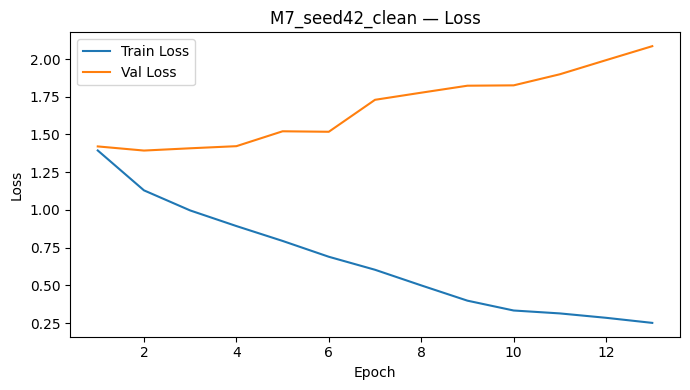

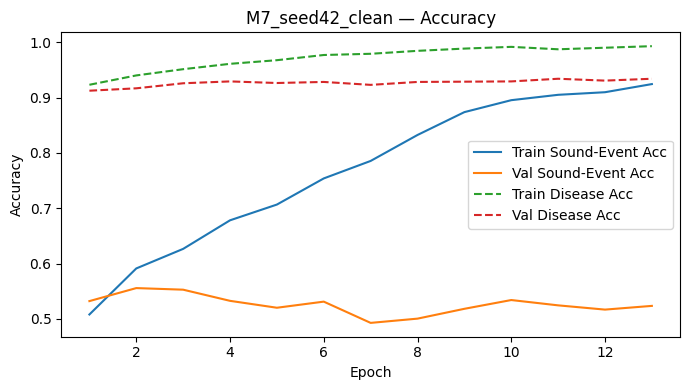

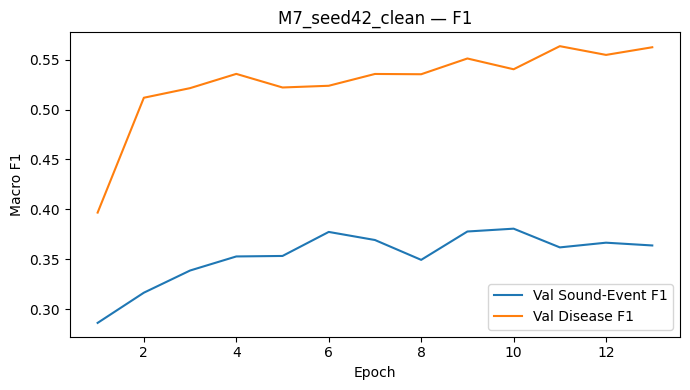

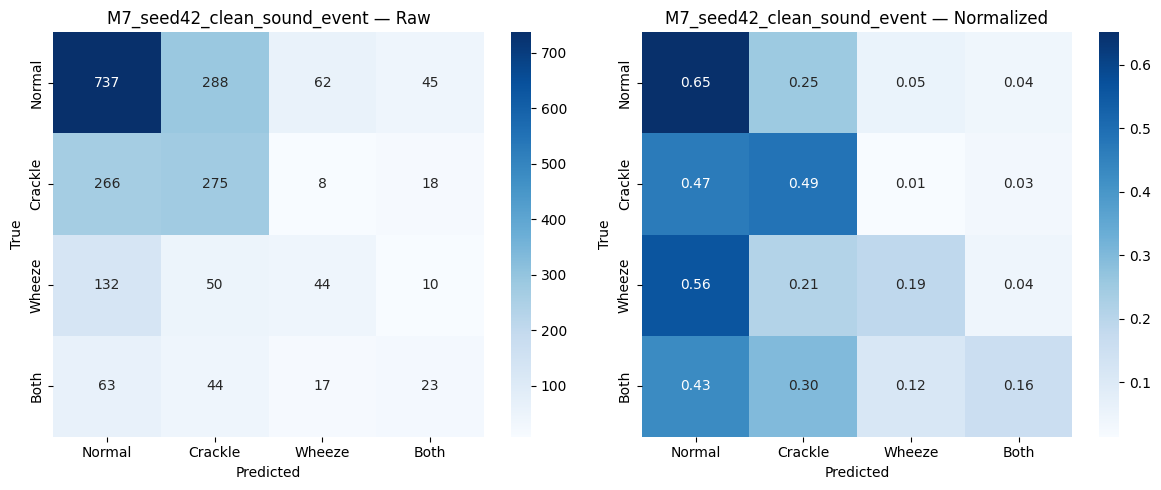

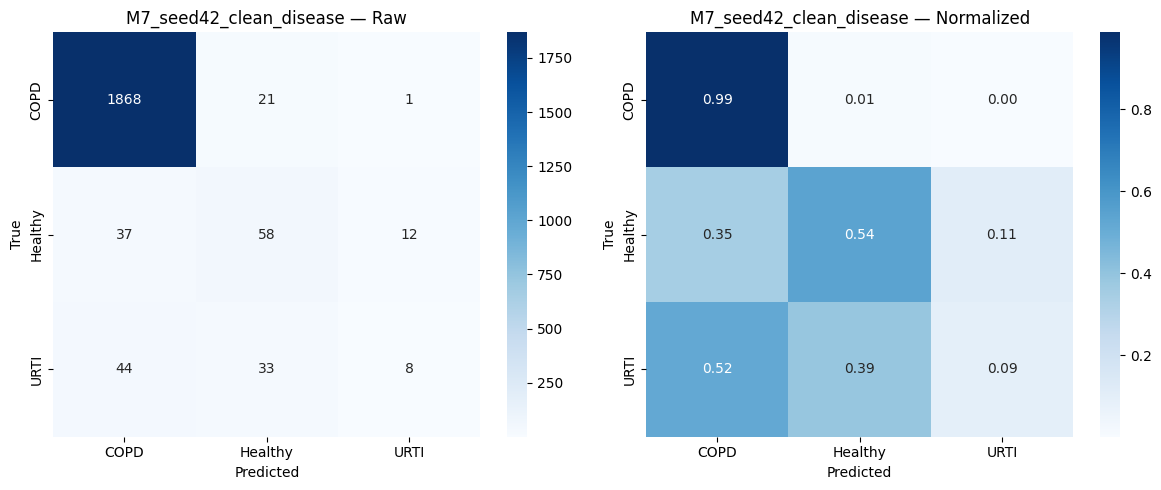


--- Seed 43 ---
Sound-Event: acc=0.5192 f1_macro=0.3608
Disease:     acc=0.9265 f1_macro=0.5603
Params: 2,232,839 total / 1,215,047 trainable | Size: 8.75 MB
Avg epoch time: 100.0s | Total train time: 999.7s


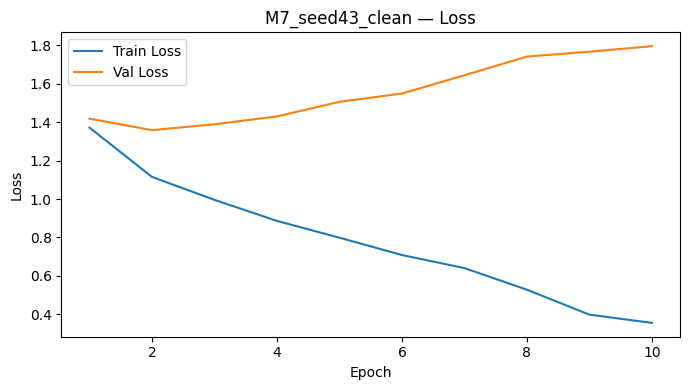

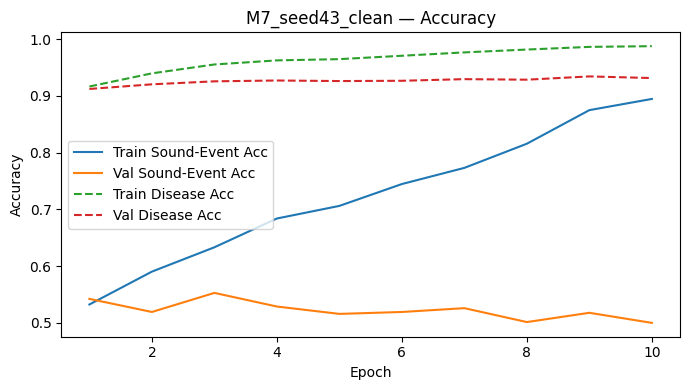

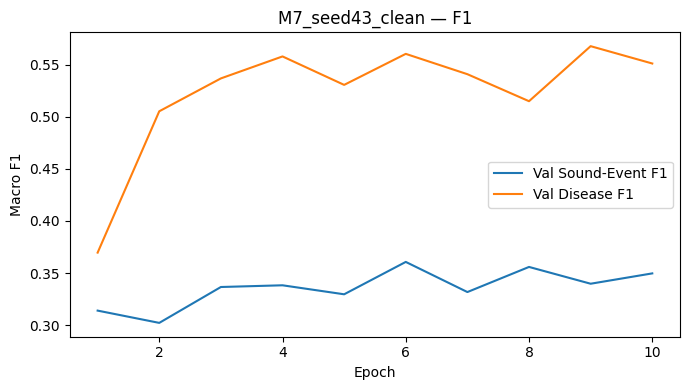

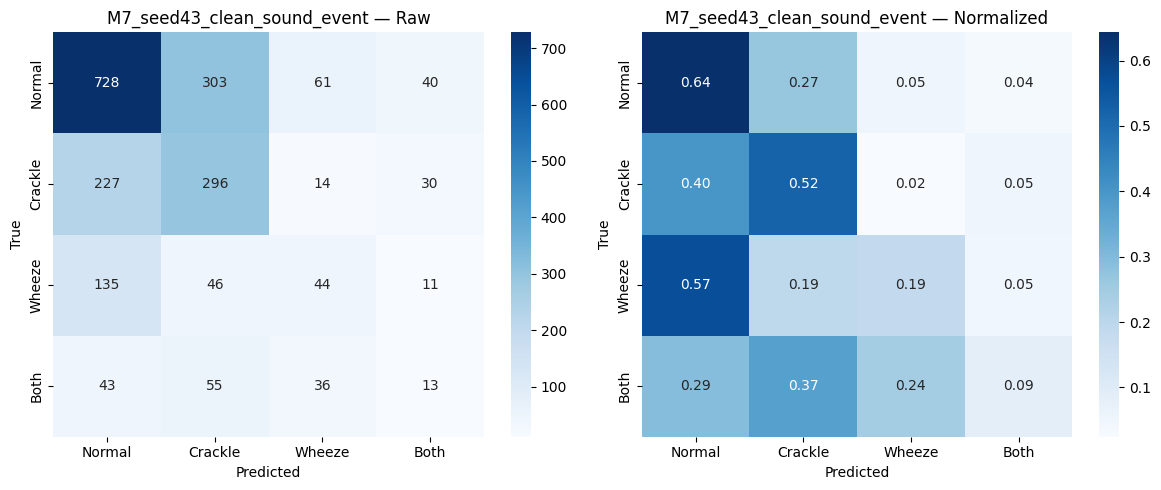

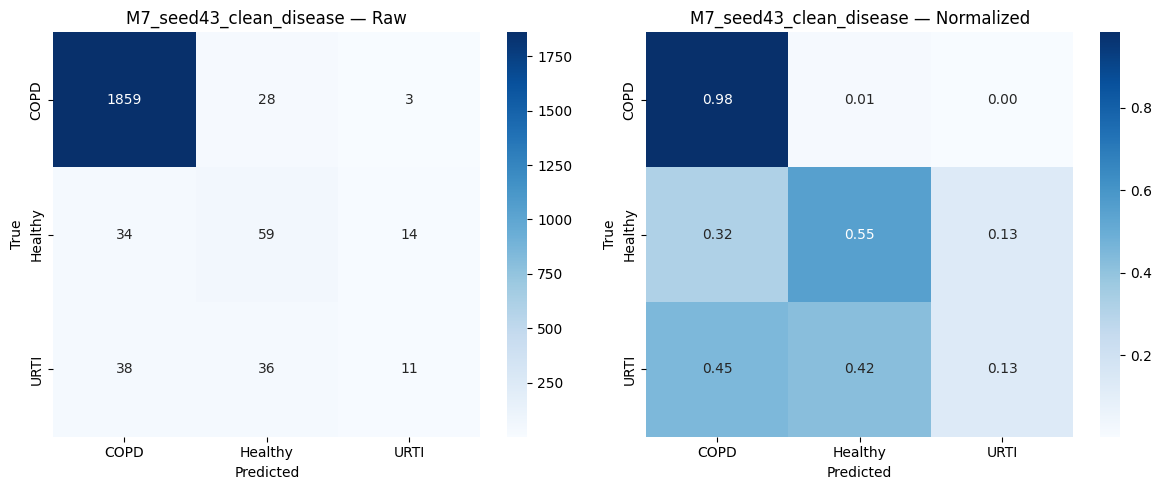


--- Seed 44 ---
Sound-Event: acc=0.5096 f1_macro=0.3602
Disease:     acc=0.9304 f1_macro=0.5404
Params: 2,232,839 total / 1,215,047 trainable | Size: 8.75 MB
Avg epoch time: 98.5s | Total train time: 788.3s


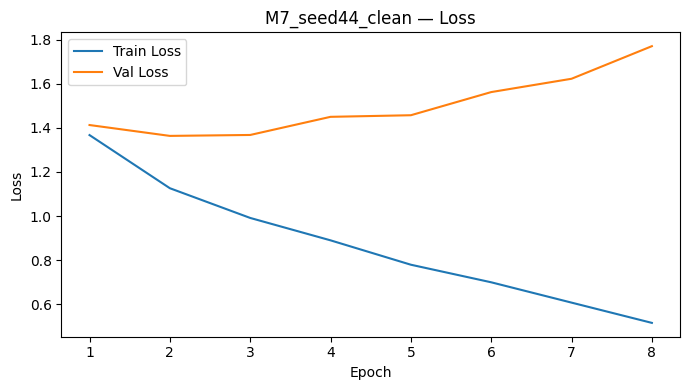

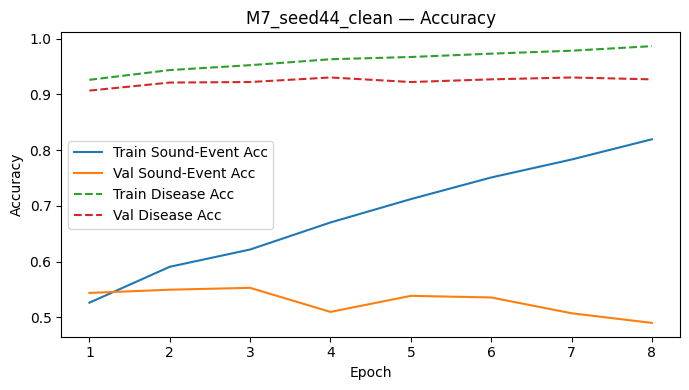

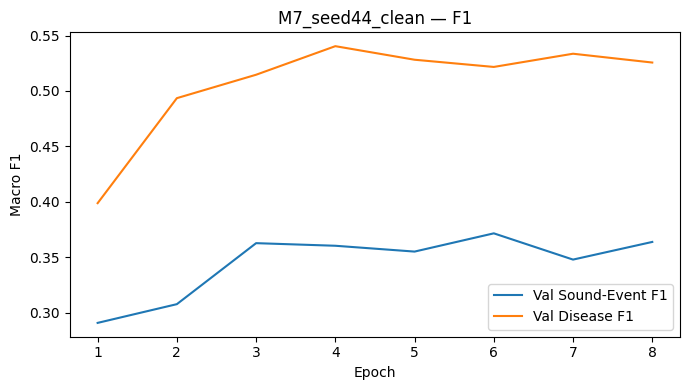

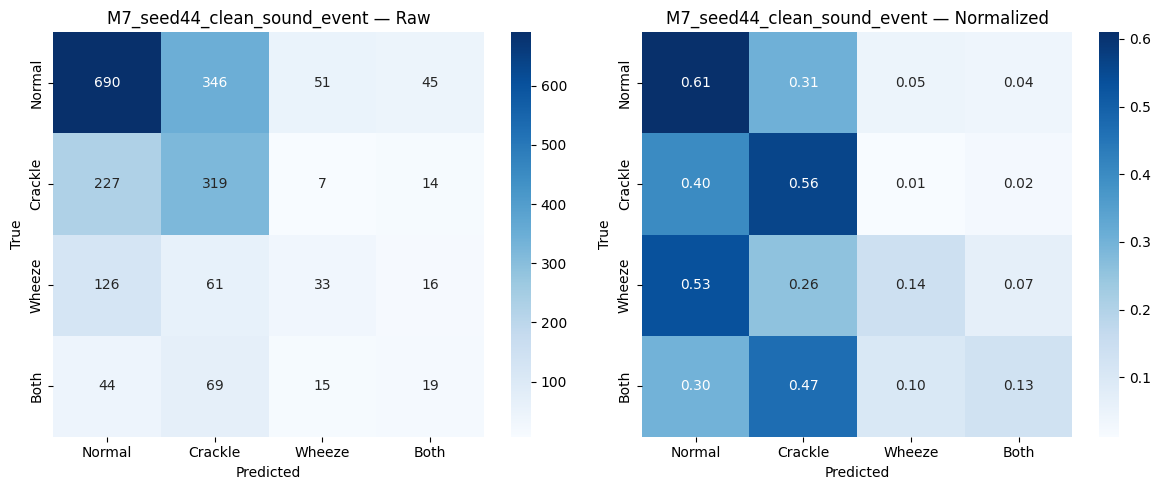

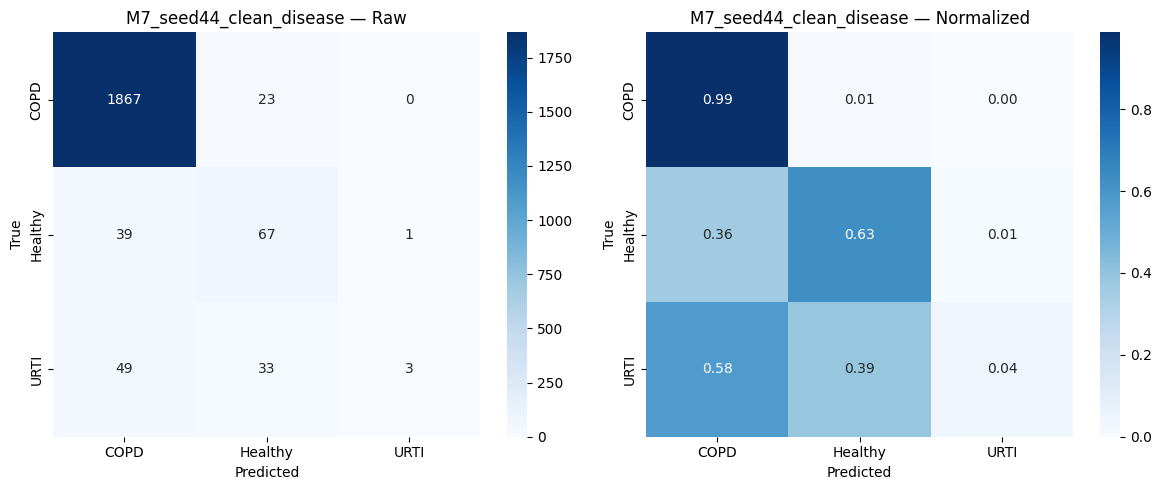


--- Seed 45 ---
Sound-Event: acc=0.5038 f1_macro=0.3503
Disease:     acc=0.9313 f1_macro=0.5384
Params: 2,232,839 total / 1,215,047 trainable | Size: 8.75 MB
Avg epoch time: 98.9s | Total train time: 692.1s


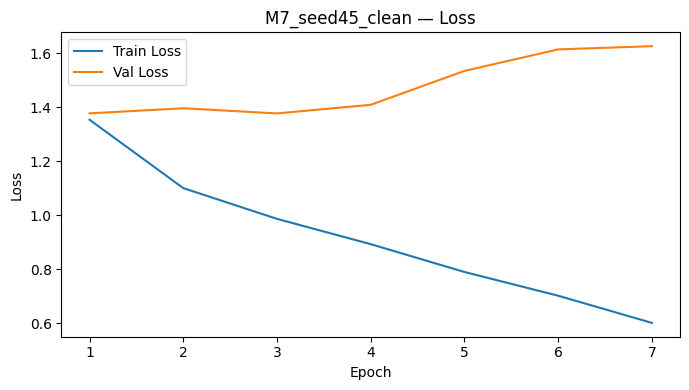

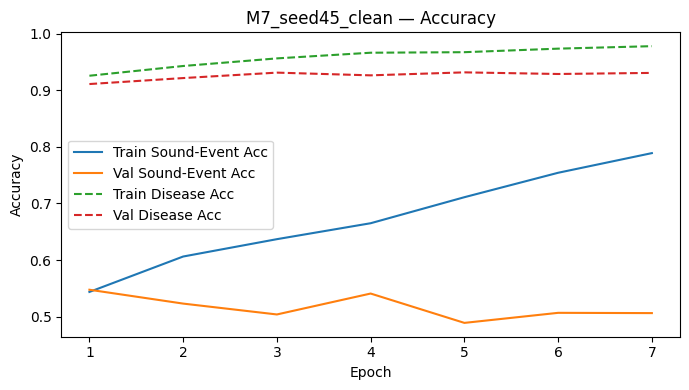

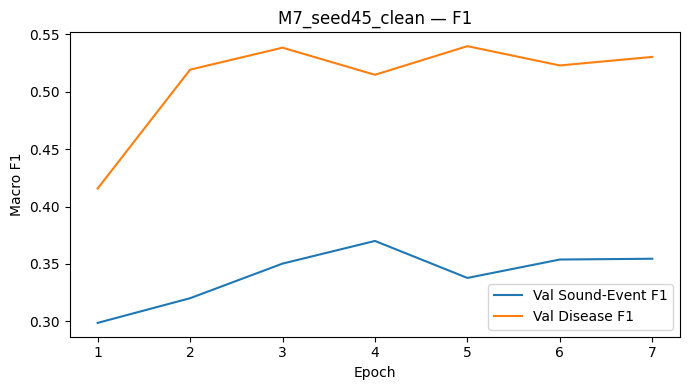

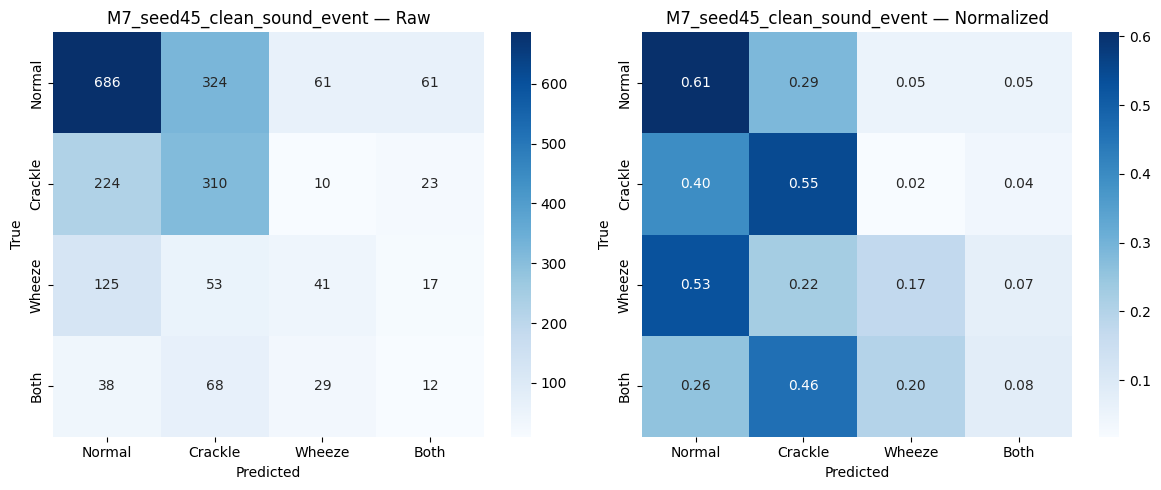

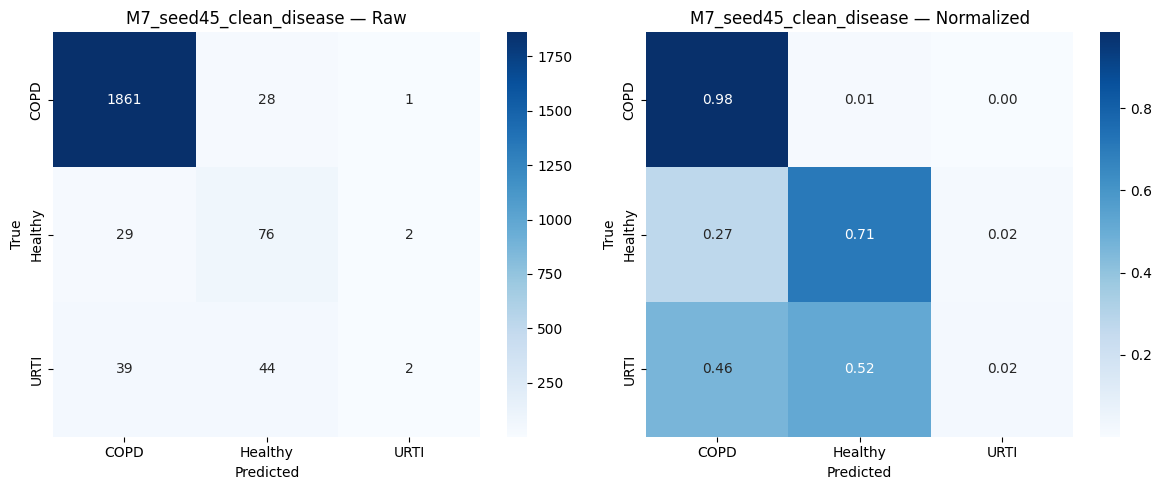


--- Seed 46 ---
Sound-Event: acc=0.5062 f1_macro=0.3857
Disease:     acc=0.9328 f1_macro=0.5348
Params: 2,232,839 total / 1,215,047 trainable | Size: 8.75 MB
Avg epoch time: 99.8s | Total train time: 1297.4s


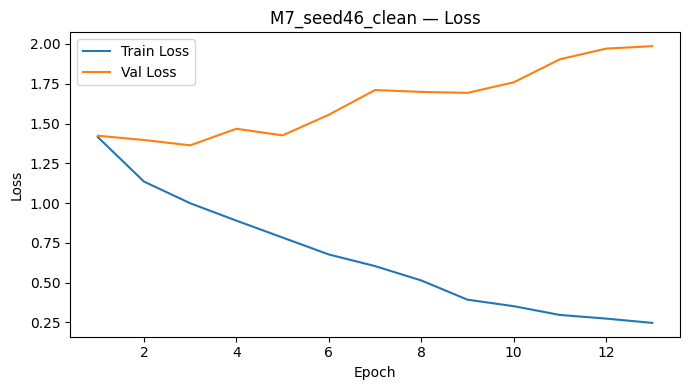

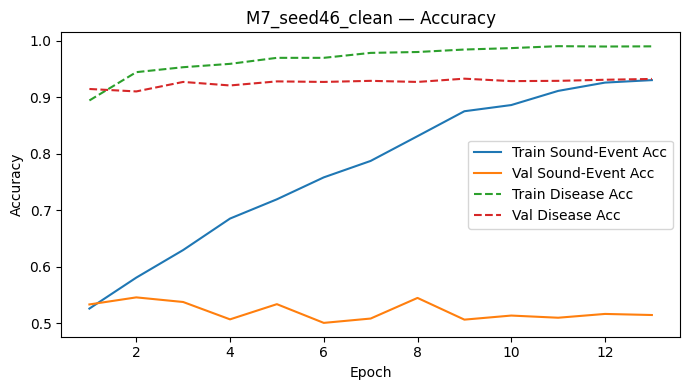

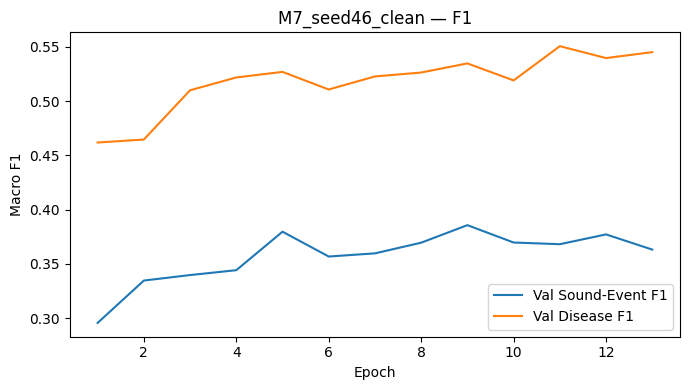

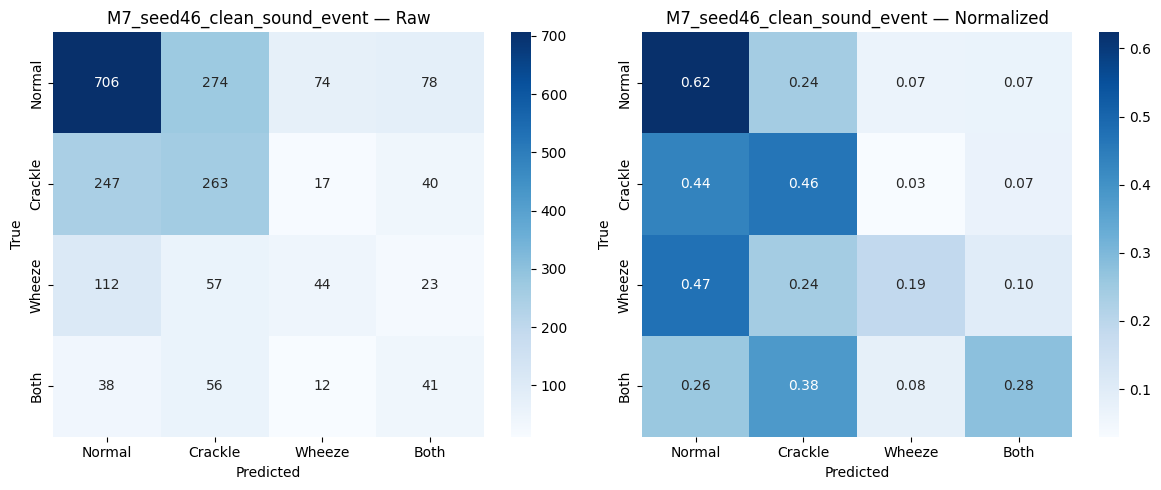

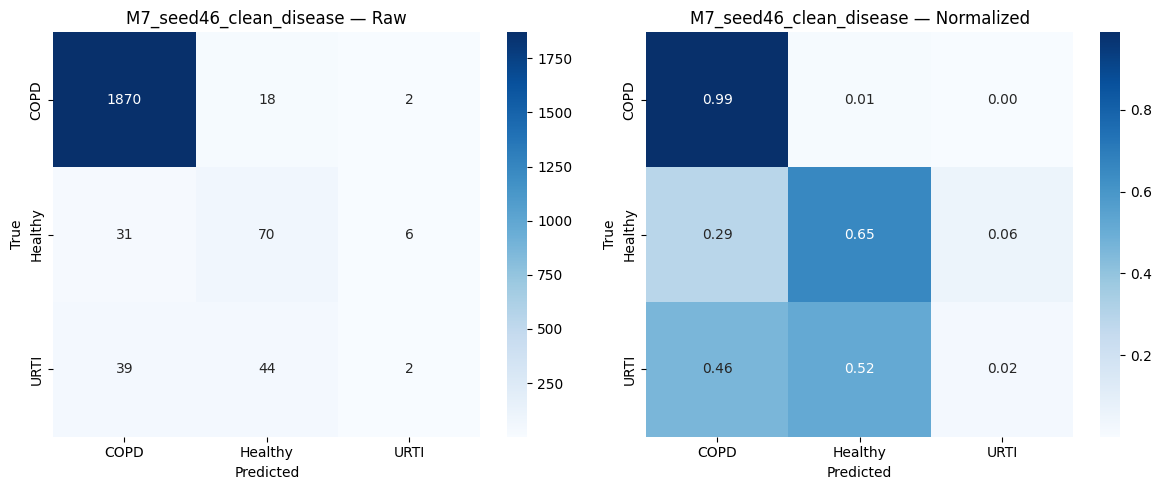


Cached member_reports_clean to /content/drive/MyDrive/M7_project/results/member_reports_clean.json -- reruns will load this instantly.


In [12]:
# ==================== CELL 22 ====================
# Cached like Cell 19/26: if member_reports_clean.json already exists on Drive, load it
# instead of reloading checkpoints and re-running inference. Set FORCE_RECOMPUTE=True to
# ignore the cache (e.g. after changing full_metric_suite_dual or the test set).

FORCE_RECOMPUTE_CLEAN_REPORT = False
_report_cache_path = f'{CONFIG["results_dir"]}/member_reports_clean.json'

if not FORCE_RECOMPUTE_CLEAN_REPORT and os.path.exists(_report_cache_path):
    with open(_report_cache_path) as f:
        member_reports_clean = json.load(f)
    print(f"Loaded cached member_reports_clean ({len(member_reports_clean)} members) from "
          f"{_report_cache_path} — skipping re-evaluation. Set FORCE_RECOMPUTE_CLEAN_REPORT=True "
          f"to force a rerun.")
    for m in member_reports_clean:
        print(f"  seed {m['seed']}: sound f1={m['sound_metrics']['f1_macro']:.4f} | "
              f"disease f1={m['disease_metrics']['f1_macro']:.4f}")
else:
    member_reports_clean = []
    for res in ensemble_results_clean:
        seed = res["seed"]
        model = load_member_from_checkpoint(seed, res["best_ckpt_path"], CONFIG, DEVICE)
        tag = f"M7_seed{seed}_clean"

        # single pass through test_loader scores BOTH heads (was two full passes before)
        sound_metrics, disease_metrics = full_metric_suite_dual(
            model, test_loader, SOUND_EVENT_CLASSES, DISEASE_CLASSES, device=DEVICE)

        total_params, trainable_params = count_params(model)
        model_size_mb = get_model_size_mb(model)
        avg_epoch_time = np.mean([h["epoch_time_s"] for h in res["history"]])

        print(f"\n--- Seed {seed} ---")
        print(f"Sound-Event: acc={sound_metrics['accuracy']:.4f} f1_macro={sound_metrics['f1_macro']:.4f}")
        print(f"Disease:     acc={disease_metrics['accuracy']:.4f} f1_macro={disease_metrics['f1_macro']:.4f}")
        print(f"Params: {total_params:,} total / {trainable_params:,} trainable | Size: {model_size_mb} MB")
        print(f"Avg epoch time: {avg_epoch_time:.1f}s | Total train time: {res['total_train_time_s']:.1f}s")

        plot_curves(res["history"], tag, CONFIG["results_dir"])
        plot_confusion(np.array(sound_metrics["confusion_matrix_raw"]), np.array(sound_metrics["confusion_matrix_normalized"]),
                       SOUND_EVENT_CLASSES, f"{tag}_sound_event", CONFIG["results_dir"])
        plot_confusion(np.array(disease_metrics["confusion_matrix_raw"]), np.array(disease_metrics["confusion_matrix_normalized"]),
                       DISEASE_CLASSES, f"{tag}_disease", CONFIG["results_dir"])
        plt.close("all")  # free matplotlib figure memory

        # y_true/y_pred/y_prob are raw numpy arrays (not JSON-safe) and unused by any later
        # cell, so they're dropped before caching -- keeps the cache file small and portable.
        sound_metrics_cacheable = {k: v for k, v in sound_metrics.items() if k not in ("y_true", "y_pred", "y_prob")}
        disease_metrics_cacheable = {k: v for k, v in disease_metrics.items() if k not in ("y_true", "y_pred", "y_prob")}

        member_reports_clean.append({
            "seed": seed, "sound_metrics": sound_metrics_cacheable, "disease_metrics": disease_metrics_cacheable,
            "total_params": total_params, "trainable_params": trainable_params,
            "model_size_mb": model_size_mb, "avg_epoch_time_s": float(avg_epoch_time),
            "total_train_time_s": res["total_train_time_s"], "history": res["history"],
        })

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    os.makedirs(CONFIG["results_dir"], exist_ok=True)
    with open(_report_cache_path, "w") as f:
        json.dump(member_reports_clean, f, indent=2)
    print(f"\nCached member_reports_clean to {_report_cache_path} -- reruns will load this instantly.")


<!-- CELL 23 -->
### Ensemble-Disagreement Unknown-Detection

For every patient (known-class test set + the 19 held-out unknown-class patients), get each of the 5
members' disease-head softmax, average them, and measure **disagreement** (mean pairwise KL / variance
across members). Known patients should show low disagreement; unknown-class patients (never seen by any
member) should show high disagreement. This disagreement score is evaluated as an unknown-vs-known
detector via AUROC/AUPR.


Unknown-detection via ensemble disagreement:
  AUROC: 0.6566
  AUPRC: 0.3968
  n_known=42, n_unknown=19
Cached disagreement results to /content/drive/MyDrive/M7_project/results/disagreement_clean.json -- reruns will load this instantly.


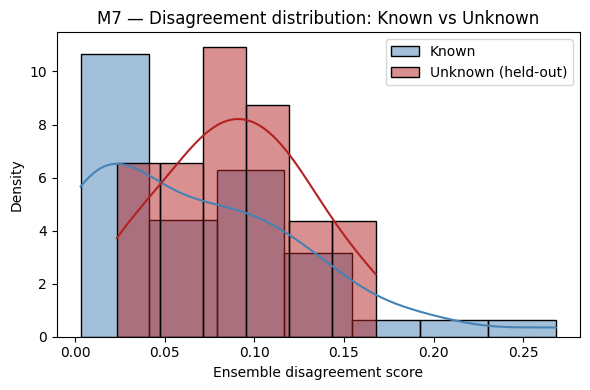

In [13]:
# ==================== CELL 24 ====================

def patient_level_disagreement(member_specs, dataset, config, device):
    """member_specs: list of (seed, ckpt_path) tuples. Loads each member from disk one at a time
    (rather than holding all N in memory) to compute per-patient mean probs + disagreement.
    Returns dict: patient_id -> {mean_probs, disagreement_score}"""
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

    all_model_probs = []  # one array per model: [n_models, n_samples, n_classes]
    all_patient_ids = None

    for seed, ckpt_path in member_specs:
        model = load_member_from_checkpoint(seed, ckpt_path, config, device)
        batch_probs, batch_pids = [], []
        with torch.no_grad():
            for mel, sound_lbl, disease_lbl, pid in loader:
                mel = mel.to(device)
                _, disease_logits = model(mel)
                probs = F.softmax(disease_logits, dim=1).cpu().numpy()
                batch_probs.append(probs)
                batch_pids.extend(list(pid))
        all_model_probs.append(np.concatenate(batch_probs, axis=0))
        if all_patient_ids is None:
            all_patient_ids = batch_pids

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    all_model_probs = np.stack(all_model_probs, axis=0)  # [n_models, n_samples, n_classes]

    df_probs = pd.DataFrame({"patient_id": all_patient_ids})
    unique_patients = df_probs["patient_id"].unique()

    results = {}
    for pid in unique_patients:
        idx = np.where(df_probs["patient_id"].values == pid)[0]
        cycle_probs = all_model_probs[:, idx, :]        # [n_models, n_cycles, n_classes]
        member_mean_probs = cycle_probs.mean(axis=1)     # [n_models, n_classes] (avg over this patient's cycles)
        ensemble_mean = member_mean_probs.mean(axis=0)    # [n_classes]

        # disagreement: mean pairwise L2 distance between member probability vectors
        n_models = member_mean_probs.shape[0]
        dists = []
        for i in range(n_models):
            for j in range(i+1, n_models):
                dists.append(np.linalg.norm(member_mean_probs[i] - member_mean_probs[j]))
        disagreement = float(np.mean(dists))

        results[pid] = {"mean_probs": ensemble_mean, "disagreement": disagreement}
    return results


# known test patients (label = known, 0) + unknown held-out patients (label = unknown, 1)
combined_eval_df = pd.concat([test_df, unknown_manifest], ignore_index=True)
combined_dataset = ICBHICycleDataset(combined_eval_df, CONFIG, augment=False)

known_patient_ids = set(test_patients)
unknown_patient_ids = set(unknown_patients["patient_id"].values)

# Cached like Cell 22/27: patient_level_disagreement reloads all 5 checkpoints and runs a
# full inference pass, identical to the Cell 22 pattern -- same fix applies here.
FORCE_RECOMPUTE_DISAGREEMENT = False
_disagreement_cache_path = f'{CONFIG["results_dir"]}/disagreement_clean.json'

if not FORCE_RECOMPUTE_DISAGREEMENT and os.path.exists(_disagreement_cache_path):
    with open(_disagreement_cache_path) as f:
        _cached = json.load(f)
    unknown_auroc = _cached["auroc"]
    unknown_auprc = _cached["auprc"]
    y_true_unknown = np.array(_cached["y_true_unknown"])
    disagreement_scores = np.array(_cached["disagreement_scores"])
    print(f"Loaded cached disagreement results from {_disagreement_cache_path} — skipping re-inference.")
    print(f"  AUROC: {unknown_auroc:.4f} | AUPRC: {unknown_auprc:.4f}")
else:
    clean_member_specs = [(res["seed"], res["best_ckpt_path"]) for res in ensemble_results_clean]
    disagreement_results = patient_level_disagreement(clean_member_specs, combined_dataset, CONFIG, DEVICE)

    y_true_unknown, disagreement_scores = [], []
    for pid, r in disagreement_results.items():
        if pid in known_patient_ids:
            y_true_unknown.append(0)
            disagreement_scores.append(r["disagreement"])
        elif pid in unknown_patient_ids:
            y_true_unknown.append(1)
            disagreement_scores.append(r["disagreement"])

    y_true_unknown = np.array(y_true_unknown)
    disagreement_scores = np.array(disagreement_scores)

    unknown_auroc = roc_auc_score(y_true_unknown, disagreement_scores)
    unknown_auprc = average_precision_score(y_true_unknown, disagreement_scores)

    print(f"Unknown-detection via ensemble disagreement:")
    print(f"  AUROC: {unknown_auroc:.4f}")
    print(f"  AUPRC: {unknown_auprc:.4f}")
    print(f"  n_known={y_true_unknown.tolist().count(0)}, n_unknown={y_true_unknown.tolist().count(1)}")

    os.makedirs(CONFIG["results_dir"], exist_ok=True)
    with open(_disagreement_cache_path, "w") as f:
        json.dump({
            "auroc": float(unknown_auroc), "auprc": float(unknown_auprc),
            "y_true_unknown": y_true_unknown.tolist(),
            "disagreement_scores": disagreement_scores.tolist(),
        }, f, indent=2)
    print(f"Cached disagreement results to {_disagreement_cache_path} -- reruns will load this instantly.")

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.histplot(disagreement_scores[y_true_unknown == 0], color="steelblue", label="Known", kde=True, ax=ax, stat="density", alpha=0.5)
sns.histplot(disagreement_scores[y_true_unknown == 1], color="firebrick", label="Unknown (held-out)", kde=True, ax=ax, stat="density", alpha=0.5)
ax.set_xlabel("Ensemble disagreement score"); ax.set_title("M7 — Disagreement distribution: Known vs Unknown")
ax.legend(); plt.tight_layout()
plt.savefig(f"{CONFIG['results_dir']}/M7_unknown_disagreement_hist.png", dpi=120)
plt.show()


<!-- CELL 25 -->
## Section 8 — Augmented Re-run (SpecAugment)

Faculty requirement #5: re-run with data augmentation on training samples, report the same full metric
suite and curves, clean vs. augmented. Uses SpecAugment (time + frequency masking on the log-mel
spectrogram) applied only to training data — test/eval data stays clean throughout.


In [14]:
# ==================== CELL 26 ====================
# Same crash-safe behaviour as Cell 19 — re-run freely.

train_dataset_aug = ICBHICycleDataset(train_df, CONFIG, augment=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=CONFIG["batch_size"], shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                              persistent_workers=(PERSISTENT_WORKERS and NUM_WORKERS > 0))

ensemble_results_aug = []
for seed in CONFIG["ensemble_seeds"]:
    result = train_one_member(seed, train_loader_aug, test_loader, CONFIG,
                              augmented=True, tag="aug")
    ensemble_results_aug.append(result)

print("\nAll 5 augmented ensemble members trained.")
for r in ensemble_results_aug:
    print(f"  seed {r['seed']}: best combined-F1 {r['best_f1']:.4f} "
          f"({r['total_train_time_s']/60:.1f} min)")



Training ensemble member seed=42 (aug)
  Params: 2,232,839 total | 1,215,047 trainable (54.4%) | weight_decay=0.0001
  no checkpoint found — starting from epoch 1


seed42 epoch1:   0%|          | 0/200 [00:00<?, ?it/s]

  epoch 1/15 | train_loss 1.4459 | val_loss 1.4663 | val_sound_f1 0.2864 | val_disease_f1 0.3172 | 107.9s


seed42 epoch2:   0%|          | 0/200 [00:00<?, ?it/s]

  epoch 2/15 | train_loss 1.2485 | val_loss 1.3622 | val_sound_f1 0.3144 | val_disease_f1 0.4684 | 106.2s


...

  epoch 13/15 | train_loss 0.9046 | val_loss 1.4724 | val_sound_f1 0.3656 | val_disease_f1 0.5409 | 110.2s


seed46 epoch14:   0%|          | 0/200 [00:00<?, ?it/s]

  epoch 14/15 | train_loss 0.8865 | val_loss 1.5557 | val_sound_f1 0.3668 | val_disease_f1 0.5428 | 111.5s


seed46 epoch15:   0%|          | 0/200 [00:00<?, ?it/s]

  epoch 15/15 | train_loss 0.8746 | val_loss 1.5505 | val_sound_f1 0.3624 | val_disease_f1 0.5331 | 111.9s
  member seed=46 (aug) DONE — marked complete, will be skipped on re-run.
[RAM after seed46 (aug)] used 4.69 GB / 13.61 GB (37.9%)  | [VRAM after seed46 (aug)] allocated 0.05 GB, reserved 0.10 GB

All 5 augmented ensemble members trained.
  seed 42: best combined-F1 0.4585 (27.1 min)
  seed 43: best combined-F1 0.4475 (21.9 min)
  seed 44: best combined-F1 0.4390 (18.5 min)
  seed 45: best combined-F1 0.4402 (22.4 min)
  seed 46: best combined-F1 0.4548 (27.9 min)



--- Seed 42 (augmented) ---
Sound-Event: acc=0.5447 f1_macro=0.3901
Disease:     acc=0.9304 f1_macro=0.5269


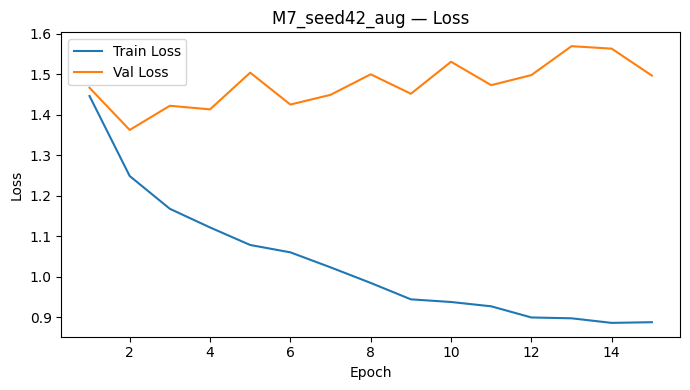

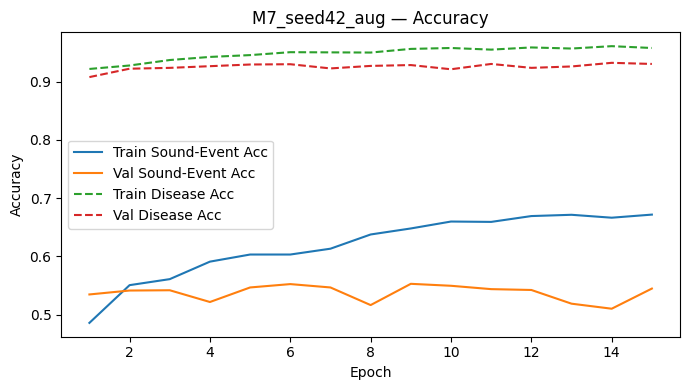

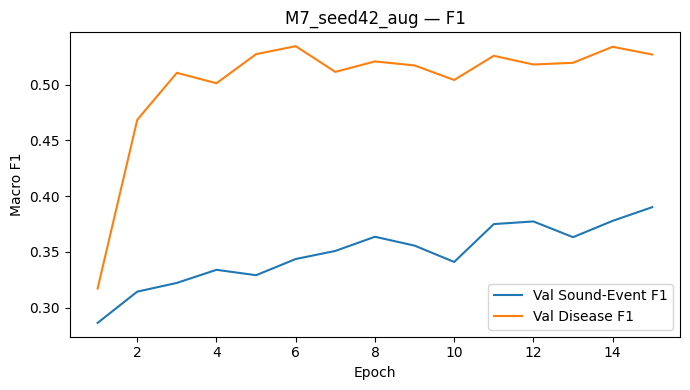

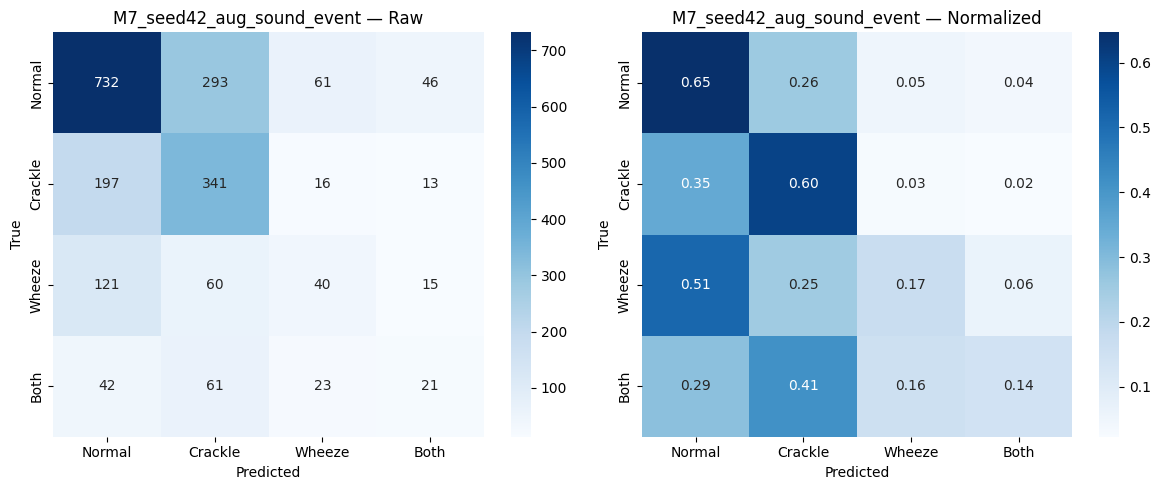

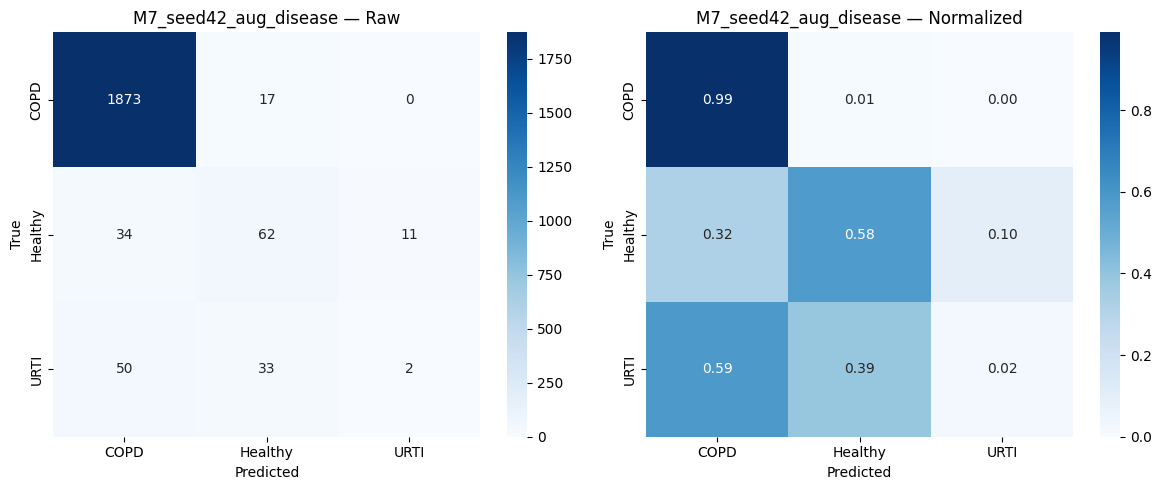


--- Seed 43 (augmented) ---
Sound-Event: acc=0.5389 f1_macro=0.3695
Disease:     acc=0.9308 f1_macro=0.5254


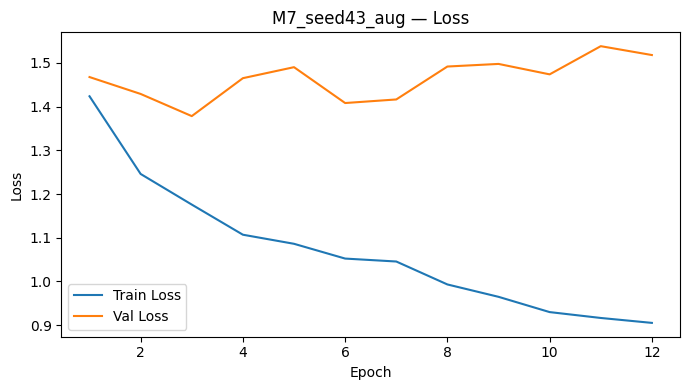

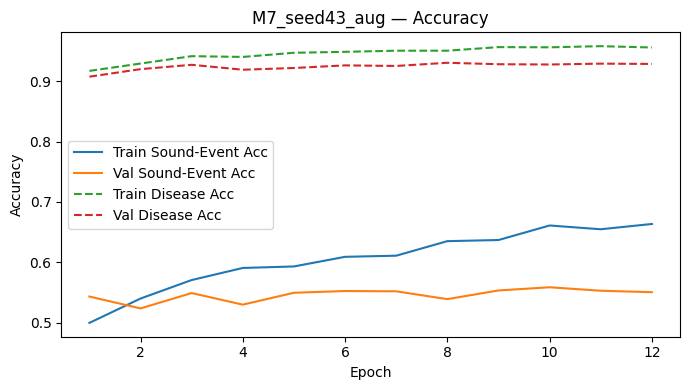

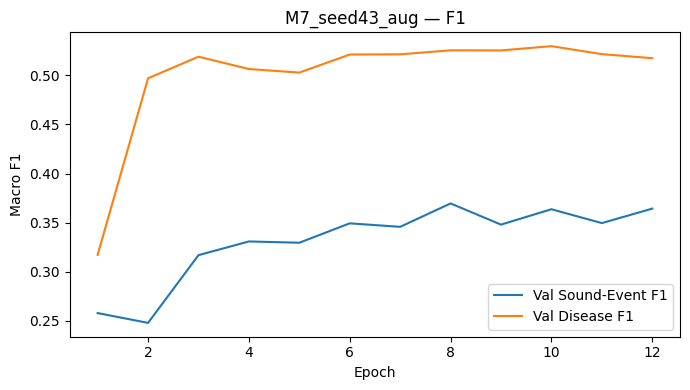

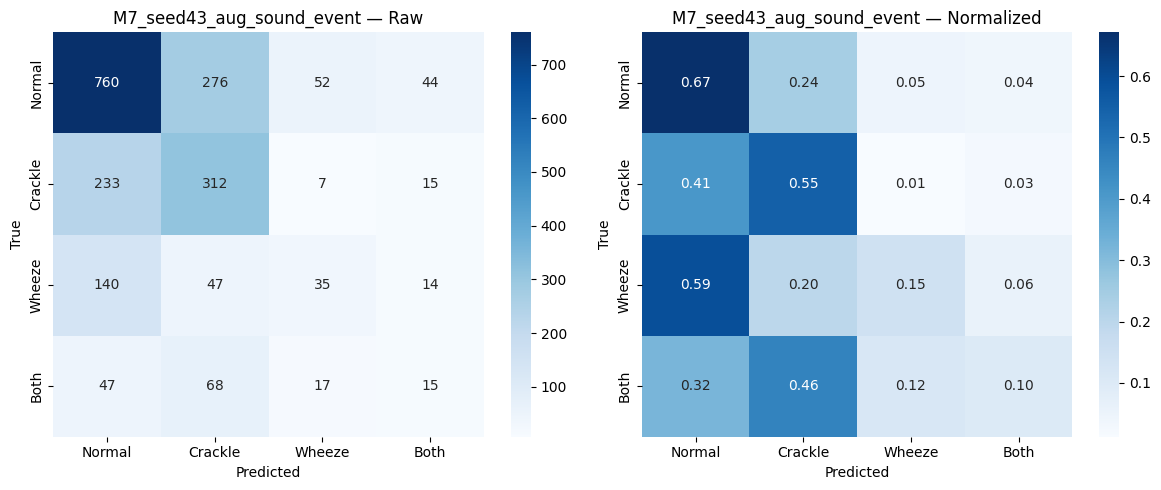

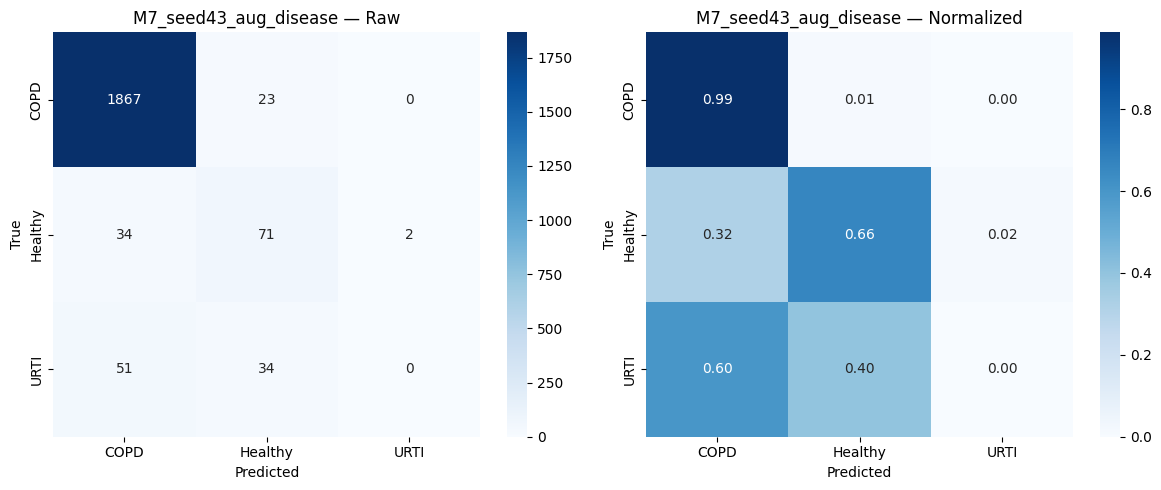


--- Seed 44 (augmented) ---
Sound-Event: acc=0.5351 f1_macro=0.3592
Disease:     acc=0.9284 f1_macro=0.5188


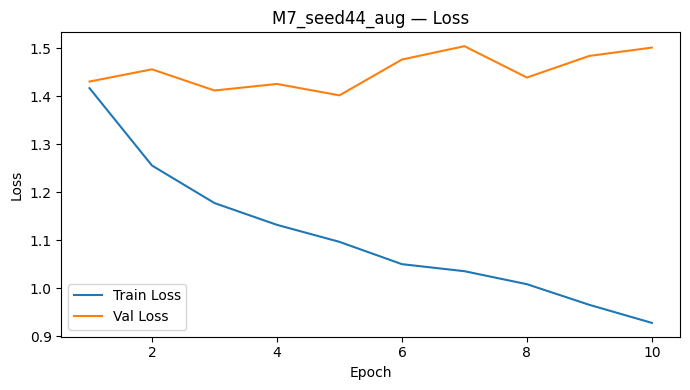

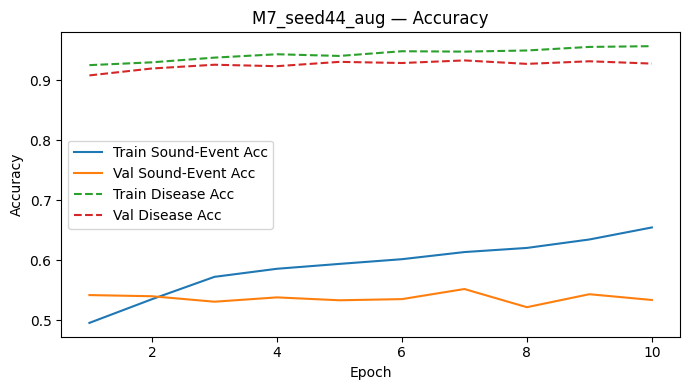

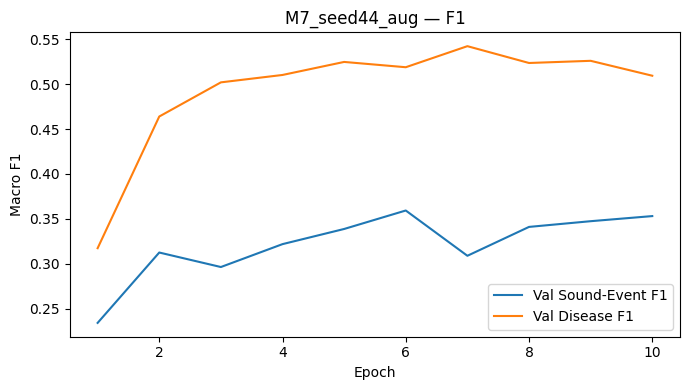

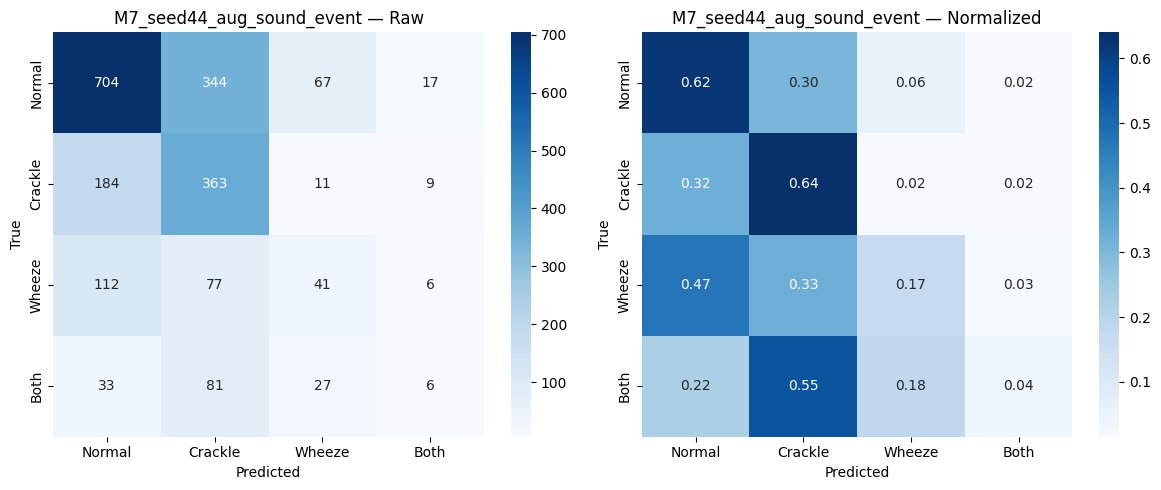

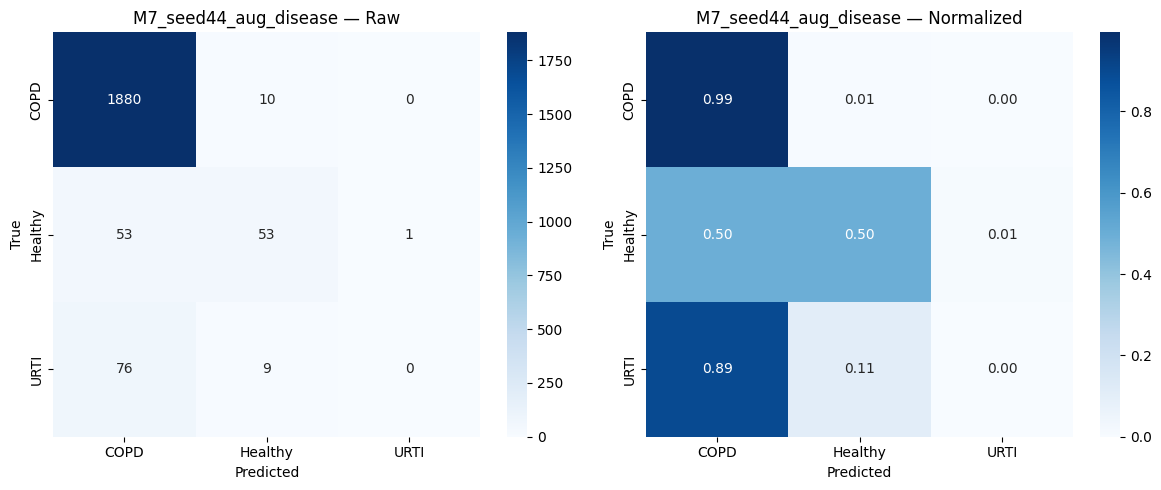


--- Seed 45 (augmented) ---
Sound-Event: acc=0.5221 f1_macro=0.3645
Disease:     acc=0.9280 f1_macro=0.5159


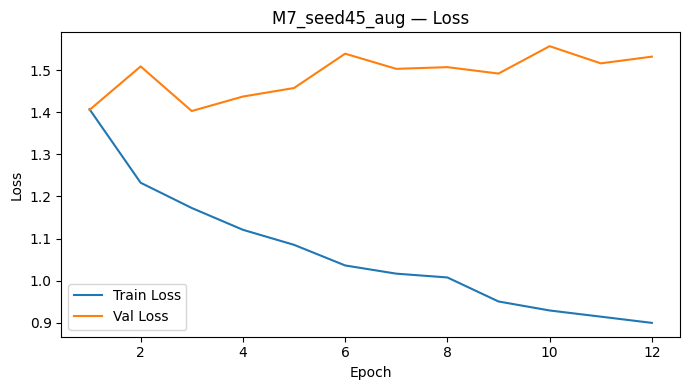

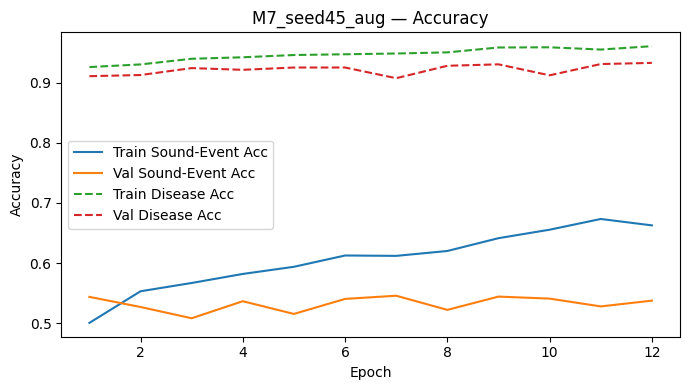

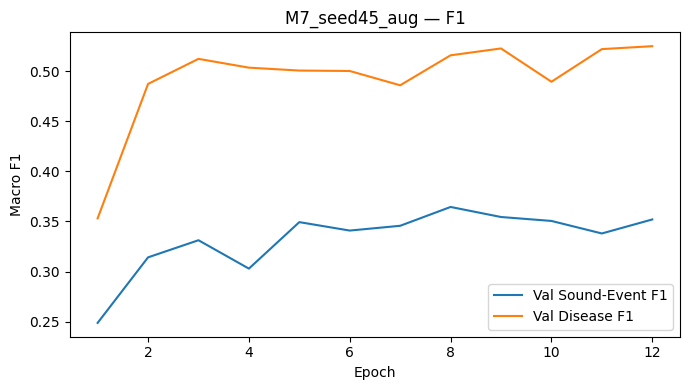

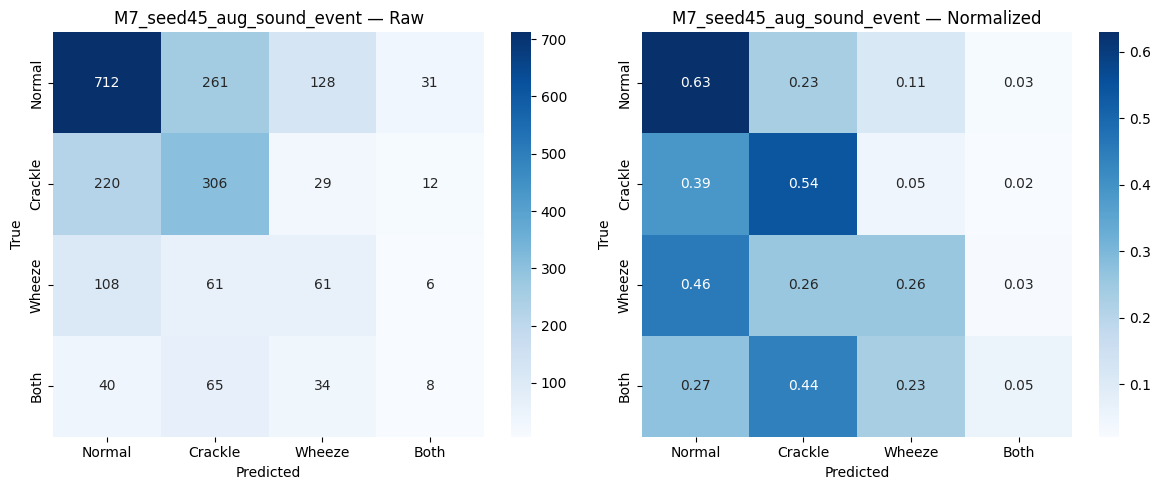

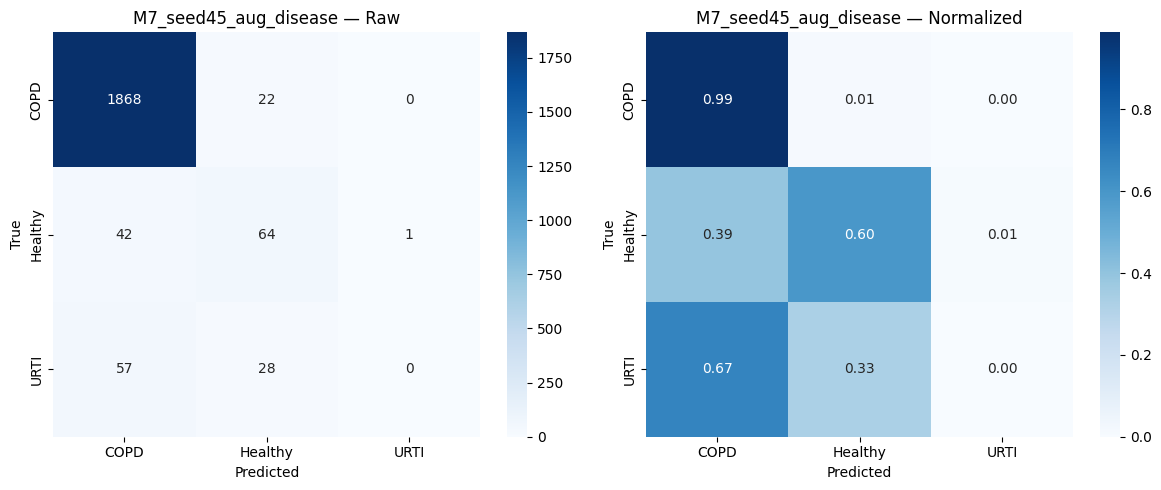


--- Seed 46 (augmented) ---
Sound-Event: acc=0.5351 f1_macro=0.3668
Disease:     acc=0.9246 f1_macro=0.5428


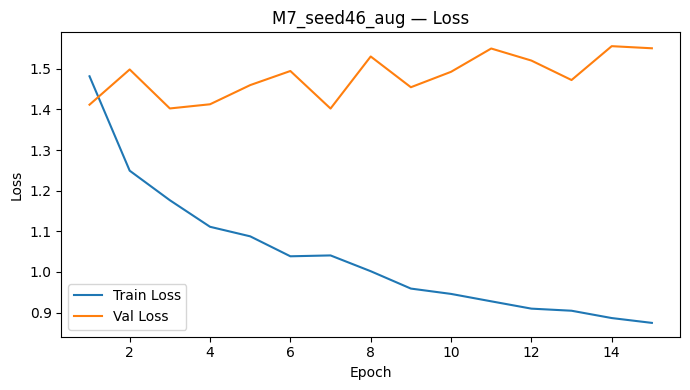

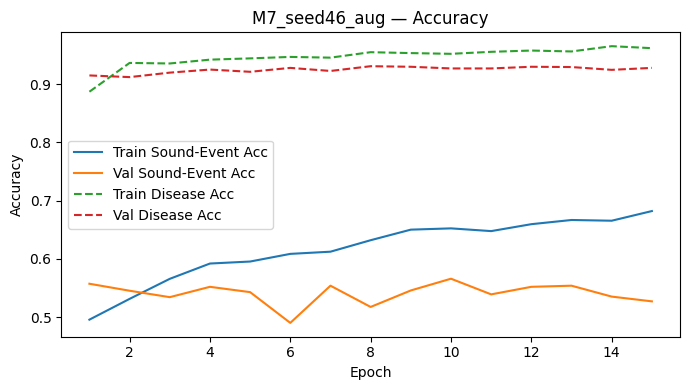

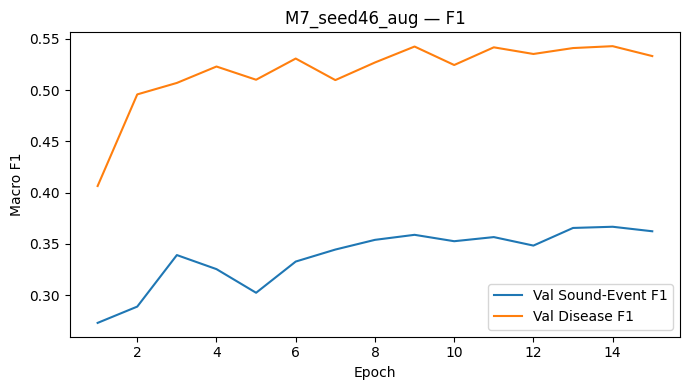

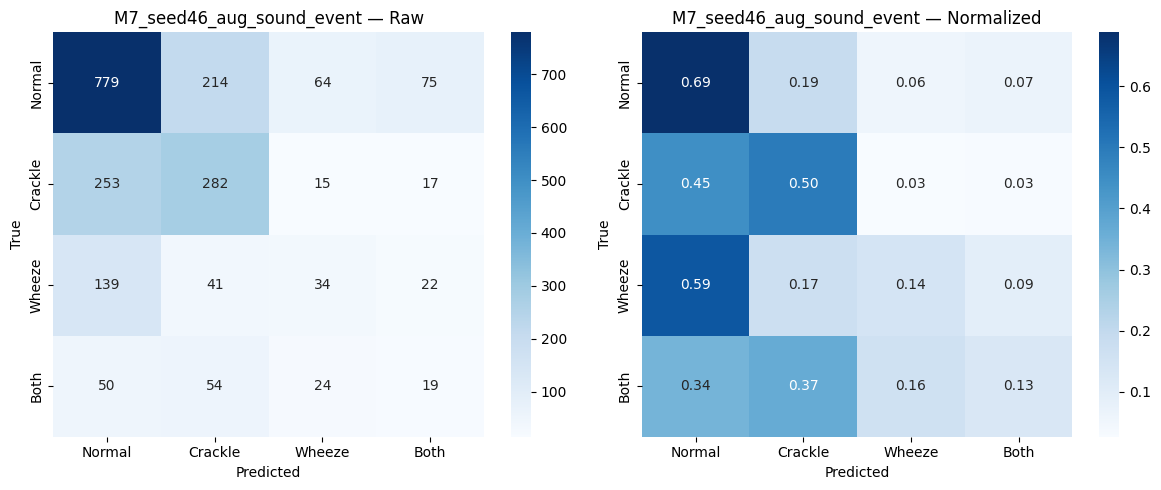

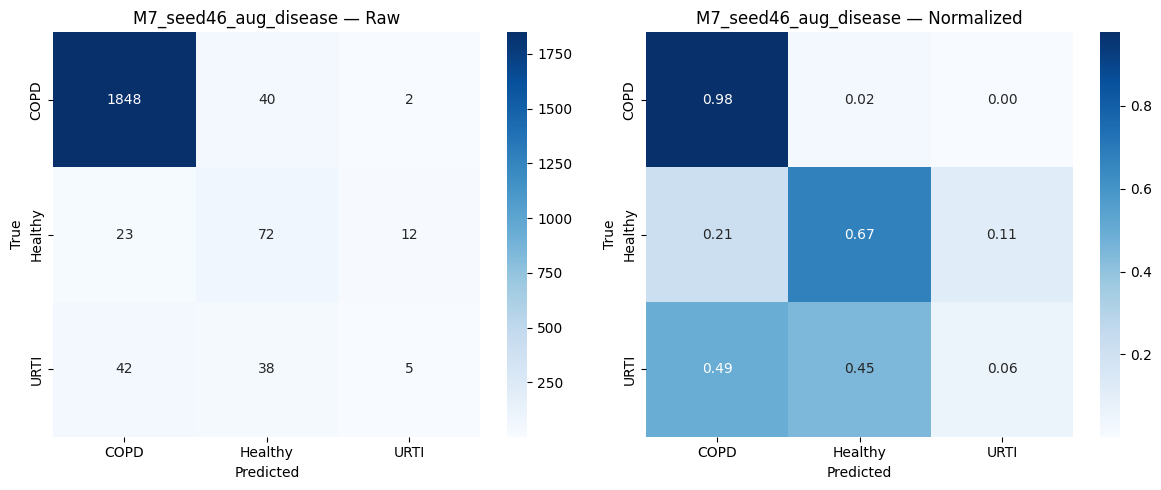


Cached member_reports_aug to /content/drive/MyDrive/M7_project/results/member_reports_aug.json -- reruns will load this instantly.

[Augmented] Unknown-detection AUROC: 0.6842 | AUPRC: 0.4354


In [15]:
# ==================== CELL 27 ====================
# Same caching + single-pass fix as Cell 22.

FORCE_RECOMPUTE_AUG_REPORT = False
_report_cache_path_aug = f'{CONFIG["results_dir"]}/member_reports_aug.json'

if not FORCE_RECOMPUTE_AUG_REPORT and os.path.exists(_report_cache_path_aug):
    with open(_report_cache_path_aug) as f:
        member_reports_aug = json.load(f)
    print(f"Loaded cached member_reports_aug ({len(member_reports_aug)} members) from "
          f"{_report_cache_path_aug} — skipping re-evaluation. Set FORCE_RECOMPUTE_AUG_REPORT=True "
          f"to force a rerun.")
    for m in member_reports_aug:
        print(f"  seed {m['seed']}: sound f1={m['sound_metrics']['f1_macro']:.4f} | "
              f"disease f1={m['disease_metrics']['f1_macro']:.4f}")
else:
    member_reports_aug = []
    for res in ensemble_results_aug:
        seed = res["seed"]
        model = load_member_from_checkpoint(seed, res["best_ckpt_path"], CONFIG, DEVICE)
        tag = f"M7_seed{seed}_aug"

        sound_metrics, disease_metrics = full_metric_suite_dual(
            model, test_loader, SOUND_EVENT_CLASSES, DISEASE_CLASSES, device=DEVICE)

        total_params, trainable_params = count_params(model)
        model_size_mb = get_model_size_mb(model)
        avg_epoch_time = np.mean([h["epoch_time_s"] for h in res["history"]])

        print(f"\n--- Seed {seed} (augmented) ---")
        print(f"Sound-Event: acc={sound_metrics['accuracy']:.4f} f1_macro={sound_metrics['f1_macro']:.4f}")
        print(f"Disease:     acc={disease_metrics['accuracy']:.4f} f1_macro={disease_metrics['f1_macro']:.4f}")

        plot_curves(res["history"], tag, CONFIG["results_dir"])
        plot_confusion(np.array(sound_metrics["confusion_matrix_raw"]), np.array(sound_metrics["confusion_matrix_normalized"]),
                       SOUND_EVENT_CLASSES, f"{tag}_sound_event", CONFIG["results_dir"])
        plot_confusion(np.array(disease_metrics["confusion_matrix_raw"]), np.array(disease_metrics["confusion_matrix_normalized"]),
                       DISEASE_CLASSES, f"{tag}_disease", CONFIG["results_dir"])
        plt.close("all")

        sound_metrics_cacheable = {k: v for k, v in sound_metrics.items() if k not in ("y_true", "y_pred", "y_prob")}
        disease_metrics_cacheable = {k: v for k, v in disease_metrics.items() if k not in ("y_true", "y_pred", "y_prob")}

        member_reports_aug.append({
            "seed": seed, "sound_metrics": sound_metrics_cacheable, "disease_metrics": disease_metrics_cacheable,
            "total_params": total_params, "trainable_params": trainable_params,
            "model_size_mb": model_size_mb, "avg_epoch_time_s": float(avg_epoch_time),
            "total_train_time_s": res["total_train_time_s"], "history": res["history"],
        })

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    os.makedirs(CONFIG["results_dir"], exist_ok=True)
    with open(_report_cache_path_aug, "w") as f:
        json.dump(member_reports_aug, f, indent=2)
    print(f"\nCached member_reports_aug to {_report_cache_path_aug} -- reruns will load this instantly.")

aug_member_specs = [(res["seed"], res["best_ckpt_path"]) for res in ensemble_results_aug]
disagreement_results_aug = patient_level_disagreement(aug_member_specs, combined_dataset, CONFIG, DEVICE)

y_true_unknown_aug, disagreement_scores_aug = [], []
for pid, r in disagreement_results_aug.items():
    if pid in known_patient_ids:
        y_true_unknown_aug.append(0); disagreement_scores_aug.append(r["disagreement"])
    elif pid in unknown_patient_ids:
        y_true_unknown_aug.append(1); disagreement_scores_aug.append(r["disagreement"])

y_true_unknown_aug = np.array(y_true_unknown_aug)
disagreement_scores_aug = np.array(disagreement_scores_aug)
unknown_auroc_aug = roc_auc_score(y_true_unknown_aug, disagreement_scores_aug)
unknown_auprc_aug = average_precision_score(y_true_unknown_aug, disagreement_scores_aug)
print(f"\n[Augmented] Unknown-detection AUROC: {unknown_auroc_aug:.4f} | AUPRC: {unknown_auprc_aug:.4f}")


<!-- CELL 28 -->
## Section 9 — Exporting Protocol-Compliant Results JSON

In [16]:
# ==================== CELL 29 ====================

def build_results_json(member_reports, ensemble_auroc, ensemble_auprc, is_augmented, augmentation_method):
    per_member_json = []
    for m in member_reports:
        per_member_json.append({
            "seed": m["seed"],
            "sound_event_metrics": {
                "accuracy": m["sound_metrics"]["accuracy"],
                "precision_macro": m["sound_metrics"]["precision_macro"],
                "recall_macro": m["sound_metrics"]["recall_macro"],
                "f1_macro": m["sound_metrics"]["f1_macro"],
                "per_class": m["sound_metrics"]["per_class"],
                "confusion_matrix_raw": m["sound_metrics"]["confusion_matrix_raw"],
                "confusion_matrix_normalized": m["sound_metrics"]["confusion_matrix_normalized"],
            },
            "disease_metrics": {
                "accuracy": m["disease_metrics"]["accuracy"],
                "precision_macro": m["disease_metrics"]["precision_macro"],
                "recall_macro": m["disease_metrics"]["recall_macro"],
                "f1_macro": m["disease_metrics"]["f1_macro"],
                "per_class": m["disease_metrics"]["per_class"],
                "confusion_matrix_raw": m["disease_metrics"]["confusion_matrix_raw"],
                "confusion_matrix_normalized": m["disease_metrics"]["confusion_matrix_normalized"],
            },
            "efficiency": {
                "total_params": m["total_params"], "trainable_params": m["trainable_params"],
                "model_size_mb": m["model_size_mb"],
                "training_time_total_s": m["total_train_time_s"],
                "training_time_per_epoch_s_avg": m["avg_epoch_time_s"],
            },
            "training_history": m["history"],
        })

    total_size_mb = sum(m["model_size_mb"] for m in member_reports)
    total_train_time = sum(m["total_train_time_s"] for m in member_reports)

    return {
        "meta": {
            "model_id": "M7", "model_name": "Deep Ensemble (N=5)",
            "member": "D", "member_name": "YOUR_NAME_HERE",
            "date_completed": time.strftime("%Y-%m-%d"),
            "is_augmented": is_augmented, "augmentation_method": augmentation_method,
            "notes": "Pretrained MobileNetV2 backbone (dual-head) used per faculty pretrained-model requirement, "
                     "in place of the team's from-scratch M1 CNN, since trained independently without team M1 checkpoint.",
        },
        "config": {
            "sample_rate": CONFIG["sample_rate"], "n_mels": CONFIG["n_mels"],
            "batch_size": CONFIG["batch_size"], "num_epochs": CONFIG["num_epochs"],
            "lr": CONFIG["lr"], "optimizer": CONFIG["optimizer"], "scheduler": CONFIG["scheduler"],
            "architecture": "MobileNetV2_pretrained_dualhead", "ensemble_seeds": CONFIG["ensemble_seeds"],
        },
        "environment": {
            "platform": "Colab",
            "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
            "pytorch_version": torch.__version__,
        },
        "dataset_info": {
            "dataset": "ICBHI_2017", "train_samples": len(train_df), "calibration_samples": len(calib_df),
            "test_samples": len(test_df), "unknown_ood_samples": len(unknown_manifest),
            "split_method": "patient_independent_60_40_with_calibration_carveout",
        },
        "ensemble_efficiency": {
            "n_members": len(member_reports),
            "total_size_mb_summed": round(total_size_mb, 2),
            "total_training_time_s_summed": round(total_train_time, 2),
        },
        "ensemble_disagreement_unknown_detection": {
            "auroc": float(ensemble_auroc), "auprc": float(ensemble_auprc),
        },
        "per_member_results": per_member_json,
        "ablation": {
            "ablation_group": "epistemic_uncertainty_method",
            "ablation_role": "baseline",
            "baseline_model_id": None,
            "variable_changed": "uncertainty_method: deep_ensemble_N5",
            "variables_held_constant": ["data_split", "loss_function", f"augmentation: {augmentation_method}"],
            "component_flags": {
                "has_sound_event_head": True, "has_disease_head": True,
                "has_cross_task_consistency": False, "has_ensemble": True,
                "n_ensemble_members": len(member_reports),
            },
        },
    }

results_json_clean = build_results_json(member_reports_clean, unknown_auroc, unknown_auprc,
                                          is_augmented=False, augmentation_method="none")
results_json_aug = build_results_json(member_reports_aug, unknown_auroc_aug, unknown_auprc_aug,
                                       is_augmented=True, augmentation_method="SpecAugment")

with open(f"{CONFIG['results_dir']}/results_M7.json", "w") as f:
    json.dump(results_json_clean, f, indent=2)
with open(f"{CONFIG['results_dir']}/results_M7_aug.json", "w") as f:
    json.dump(results_json_aug, f, indent=2)

print("Saved results_M7.json and results_M7_aug.json")


Saved results_M7.json and results_M7_aug.json


<!-- CELL 30 -->
## Section 10 — Team Handoff Download Cell

In [17]:
# ==================== CELL 31 ====================

handoff_zip = "/content/M7_handoff.zip"
with zipfile.ZipFile(handoff_zip, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(CONFIG["results_dir"]):
        zf.write(os.path.join(CONFIG["results_dir"], fname), arcname=fname)
    for res in ensemble_results_clean:
        zf.write(res["best_ckpt_path"], arcname=os.path.basename(res["best_ckpt_path"]))
    for res in ensemble_results_aug:
        zf.write(res["best_ckpt_path"], arcname=os.path.basename(res["best_ckpt_path"]))

print(f"Handoff bundle: {handoff_zip}")

try:
    from google.colab import files
    files.download(handoff_zip)
except Exception as e:
    print("Not in Colab or download blocked; file is at:", handoff_zip)


Handoff bundle: /content/M7_handoff.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<!-- CELL 32 -->
## Section 11 — Summary & Key Takeaways

- Trained **5 independently-seeded ensemble members** (pretrained MobileNetV2 backbone, dual-head:
  sound-event + disease) on ICBHI 2017, patient-independent split, clean and SpecAugment-augmented.
- Reported the full metric suite (accuracy/precision/recall/F1 macro+per-class, confusion matrices,
  model size, parameter count, training time) **per member**, for both clean and augmented runs.
- Computed the **ensemble-disagreement score** and its unknown-detection AUROC/AUPR against the 19
  held-out unknown-class patients (Bronchiectasis/Pneumonia/Bronchiolitis) — this is the core Member-D
  deliverable for M7: a gold-standard epistemic-uncertainty baseline to be compared later (M20) against
  Member B's cross-task consistency disagreement score.
- All results exported in the project's standard `results_M<ID>.json` schema for eventual merge into
  the Model Zoo appendix (M28).

**Next steps in your Member-D pipeline (per Model_Training_Reference.md):**
M8 (MC-Dropout) or M9 (SNGP) as the Tier-3 alternative uncertainty signal → M11 (post-hoc calibrators,
requires this M7 output) → M14/M20 (conformal wrapper).
